# Reto SURA 2026 — Análisis Exploratorio de Datos
**Entorno:** Databricks | **Catálogo:** `sura.datos`

El presente Análisis Exploratorio de Datos cubre los hallazgos presentados en el documento de Diagnóstico y Análisis. Este notebook incluye:

1. Carga de datos desde Unity Catalog
2. Dimensión de la operación
3. Distribución geográfica
4. Análisis de órdenes de compra
5. Análisis de programaciones y cancelaciones
6. Caracterización de la demanda empresarial
7. Catálogo de habilitaciones (oferta)
8. Problemas identificados — evidencia cuantitativa

## 0. Configuración

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pyspark.sql import functions as F

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.figsize": (12, 6), "figure.dpi": 120,
                     "axes.titlesize": 14, "axes.labelsize": 12})

SURA_BLUE   = "#0033A0"
SURA_MED    = "#2D6DF6"
SURA_LIGHT  = "#81B1FF"
SURA_ACCENT = "#00AEC7"
SURA_PAL    = [SURA_BLUE, SURA_MED, SURA_LIGHT, SURA_ACCENT,
               "#E3E829", "#888B8D", "#DFEAFF", "#D5F5F8"]

CATALOG = "sura"
SCHEMA  = "datos"
DB      = f"{CATALOG}.{SCHEMA}"

# ── Parser: tabla cargada como texto plano (columna única "value") ────────
def parse_text_table(raw_df, col_names, delimiter="\t"):
    """
    Convierte un DataFrame con columna única "value" (texto plano)
    en un DataFrame con columnas nombradas.
    Detecta y descarta la fila de encabezado si está presente en los datos.
    """
    if "value" not in raw_df.columns:
        return raw_df  # ya viene parseado con esquema
    split_col   = F.split(F.col("value"), delimiter)
    select_expr = [split_col.getItem(i).alias(name)
                   for i, name in enumerate(col_names)]
    # Descarta la fila de encabezado si el primer campo coincide con col_names[0]
    return (raw_df
            .filter(~F.col("value").startswith(col_names[0]))
            .select(*select_expr))

# ── Nombres de columnas de cada archivo (del encabezado original) ─────────
COLS_ORDENADO = [
    "Ord_Plan_Vers_Act_Id","Numero_Consecutivo_Orden","Numero_Consecutivo_Plan",
    "Dni_Prestador_Externo","Nombre_Prestador_Externo","Email_Prestador_Externo",
    "Telefono_Prestador_Externo","Numero_Cantidad_Cronograma","Numero_Cantidad_Pedida",
    "Numero_Saldo_Ejecutado","Numero_Saldo_Tarea","Codigo_Estado_Orden",
    "Estado_Orden_Desc","Nombre_Regional","Codigo_Tarea","Tarea_Desc",
    "Fecha_Aprobacion_Tarea","Dni_Elaboro_Oc","Nombre_Elaboro_Oc","Numero_Version",
    "Numero_Actividad","Fecha_Creacion_Orden","Fecha_Entrega_Servicio",
    "Fecha_Entrega_Servicio_Fin","Valor_Costo_Unitario","Valor_Costo_Total_Tarea_Cal",
    "Valor_Costo_Total_Tarea","Valor_Costo_Transporte","Valor_Costo_Viaticos",
    "Tipo_Red_Desc","Observaciones_Desc","Codigo_Producto","Producto_Desc",
    "Codigo_Uen_Cr","Uen_Cr_Desc","Oficina_Cronograma_Id","Oficina_Cronograma_Desc",
    "Pct_Cu_Cronograma","Dni_Ppr_Cronograma","Nombre_Ppr_Cronograma","Dni_Prestador",
    "Municipio_Prestador_Id","Municipio_Prestador_Desc","Nombre_Prestador",
    "Municipio_Origen_Id","Municipio_Origen_Desc","Municipio_Entrega_Id",
    "Municipio_Entrega_Desc","Codigo_Clasificacion","Clasificacion_Desc","Codigo_Area",
    "Ind_Requiere_Informe","Ind_Informe_Obligatorio","Estado_Girop_Desc",
    "Estado_Micrositio_Desc","Numero_Cantidad_Cancelada","Centro_Trabajo_Id",
    "Centro_Trabajo_Desc","Codigo_Tipo_Profesional","Perfil_Prof_Distribuidor",
    "Codigo_Perfil_Prestador","Perfil_Prestador","Email_Prestador","Telefono_Prestador",
    "Dni_Profesional_Ppal","Nombre_Ppr_Ppal","Codigo_Uen_Ppal","Tipo_Asesor",
    "Codigo_Proceso_Bloque","Proceso_Bloque_Desc","Contrato_Arl_Id","Nombre_Empresa",
    "Dni_Empresa","Contacto_Empresa_Desc","Telefono_Empresa_Desc",
    "Oficina_Ppal_Empresa_Id","Oficina_Ppal_Empresa_Desc","Macrosegmentacion_Desc",
    "Grupo_Economico_Desc","Actividad_Economica_Desc","Numero_Consecutivo_Prioridad",
    "Motivo_Prioridad_Desc","Codigo_Tipo_Entrega","Tipo_Entrega_Desc","Numero_Sigal",
    "Codigo_Cups","Codigo_Unidad_Medida","Departamento_Entrega_Desc",
    "Codigo_Delegacion_Distribuidor","Oficina_Distribuidor_Desc",
    "Fuente_Ingresa_Orden_Txt","Codigo_Poblacion_Op","Poblaciones_Cgr_Desc",
    "Ind_Liquidar_Transporte","Dni_Usuario_Modifica","Nombre_Usuario_Modifica_Txt",
    "Ind_Reactivacion","Tipo_Transporte_Txt","Ind_Transporte_Ida","Ind_Compensacion",
]  # 100 columnas

COLS_TAREAS = [
    "NMCONSECUTIVO_ORDEN","NMCONSECUTIVO_PLAN","NMACTIVIDAD","NMVERSION",
    "DNI_DISTRIBUIDOR","NOMBRE_DISTRIBUIDOR","DNI_PRESTADOR","NOMBRE_PRESTADOR",
    "TIPO_DE_ASESOR","DNI_EMPRESA","DSNOMBRE_EMPRESA","NPOLIZA","CDSUCURSAL_ENTREGA",
    "CDTAREA","DSTAREA","SNREQUIERE_INFORME","CLASIFICACION","CDPRODUCTO","DSPRODUCTO",
    "CDUEN_CRONOGRAMA","OFICINA_CRONOGRAMA","CD_MUNICIPIO_ORIGEN","DS_MUNICIPIO_ORIGEN",
    "CD_MUNICIPIO_DESTINO","DS_MUNICIPIO_DESTINO","TIPO_PROGRAMACION",
    "FEENTREGA_SERVICIO_INI","FEENTREGA_SERVICIO_FIN","DNI_PPR_ASIGNADO_EMPRESA",
    "NOM_PPR_ASIGNADO_EMPRESA","FECREACION_OC","FEPROGRAMACION","FEINGRESO_CUMPLIMIENTO",
    "NMCANTIDAD_PEDIDA","NMCANTIDAD_PROGRAMADA","DURACION","CANTIDAD_PROGRAMADA_CITA",
    "NMCANTIDAD_EJECUTADA","NMASISTENTES","DNI_INGRESA_PROGRAMACION",
    "NOMBRE_INGRESA_PROGRAMACION","DSESTADO_PROGRAMACION","DNI_INGRESA_CUMPLIMIENTO",
    "NOMBRE_INGRESA_CUMPLIMIENTO","FECANCELACION","MOTIVO_CANCELACION",
    "SNCANCELA_EMPRESA","DNI_CANCELA_PROGRAMACION","NOMBRE_CANCELA_PROGRAMACION",
    "FEENVIO_INFORME","DNI_ENVIO_INFORME","DSESTADO_INFORME",
    "OBSERVACIONES_INF_RECHAZADO","FEAPROBACION_INFORME","FERECHAZO_INFORME",
    "SNAPROBADO_AUTOMATICO","SNPARCIAL","OBSERVACIONES_PROGRAMACION",
    "CORREO_CONTACTO","NOMBRE_CONTACTO","DSCELULAR_CONTACTO","FECHA_CARGA",
]  # 62 columnas

COLS_EMPRESAS = [
    "Empresa_Id","ESTADO_EMPRESA_CALCULADO","ID_PROFESIONAL_PPAL","ESTADO_EMPRESA",
    "Fecha_Inicio_Cobertura","Fecha_Fin_Cobertura","Actividad_Economica_Desc",
    "Ind_Multiregional","Ind_Afiliada","Afiliados","Numero_Afiliados",
    "Sector_Economico_Desc","Segmentacion_Arl_Desc","GRUPO_ECONOMICO_ARL_ID",
    "UEN_PPAL_ARL_ID","Ruta_Atencion",
]  # 16 columnas

COLS_CATALOGO = [
    "DNI_PRESTADOR","NOMBRE_PRESTADOR","CDOFICINA","DSOFICINA","DNI_DISTRIBUIDOR",
    "NOMBRE_DISTRIBUIDOR","CDPRODUCTO","DSPRODUCTO","CDBLOQUE","DSBLOQUE",
    "CDTAREA","DSTAREA","CDCLASIFICACION","PTCALIFICACION","PTVALOR_TAREA",
    "SNVALIDADO","FEVALIDACION","DNI_INGRESO","DNI_MODIFICA","FEALTA_TAREA_PRESTADOR",
    "FUNCION_PRESTADOR","PERFIL_TARIFA","TIPO_DE_RED","FEALTA_PRESTADOR","FEALTA_DIST",
    "DSCLASIFICACION","CDMUNICIPIO","DSMUNICIPIO","DSTIPO_PERFIL",
    "SNCONTROLAR_HORAS_MES","PERIODO_CONSULTA_CAPACIDAD","CDMUNICIPIO_ORIGEN_OC",
    "DSMUNICIPIO_ORIGEN_OC","CAPACIDAD","FEC_INI_COS_TAR","FEC_FIN_COS_TAR",
    "FECHA_CARGA",
]  # 37 columnas

print(f"Apuntando a catálogo: {DB}")

# ── safe_toPandas: recodifica bytes cp1252 a UTF-8 válido antes de Arrow ────
def safe_toPandas(spark_df):
    """
    Los archivos cp1252 quedan en Delta con bytes crudos (ej. 0xD3 = Ó) que
    Arrow rechaza como UTF-8 inválido — tanto en toPandas() como en collect().
    Solución: re-codificar en Spark via cast→binary→decode(ISO-8859-1) para
    producir UTF-8 válido antes de que Arrow serialice la respuesta.
    """
    from pyspark.sql.types import StringType
    str_cols = [f.name for f in spark_df.schema.fields
                if isinstance(f.dataType, StringType)]
    df = spark_df
    for col_name in str_cols:
        df = df.withColumn(
            col_name,
            F.decode(F.col(col_name).cast("binary"), "ISO-8859-1")
        )
    rows = df.collect()
    if not rows:
        return pd.DataFrame(columns=spark_df.columns)
    return pd.DataFrame([row.asDict() for row in rows], columns=spark_df.columns)

print("Parser y esquemas listos")

Apuntando a catálogo: sura.datos
Parser y esquemas listos


## 1. Carga de datos desde Unity Catalog

In [0]:
# --- 1.1 Órdenes de compra ---
raw = spark.table(f"{DB}.ordenado")
ordenes_sp = parse_text_table(raw, COLS_ORDENADO, delimiter="\t")
print(f"ordenado: {ordenes_sp.count():,} filas × {len(ordenes_sp.columns)} columnas")
display(ordenes_sp.limit(3))

ordenado: 607,331 filas × 100 columnas


Ord_Plan_Vers_Act_Id,Numero_Consecutivo_Orden,Numero_Consecutivo_Plan,Dni_Prestador_Externo,Nombre_Prestador_Externo,Email_Prestador_Externo,Telefono_Prestador_Externo,Numero_Cantidad_Cronograma,Numero_Cantidad_Pedida,Numero_Saldo_Ejecutado,Numero_Saldo_Tarea,Codigo_Estado_Orden,Estado_Orden_Desc,Nombre_Regional,Codigo_Tarea,Tarea_Desc,Fecha_Aprobacion_Tarea,Dni_Elaboro_Oc,Nombre_Elaboro_Oc,Numero_Version,Numero_Actividad,Fecha_Creacion_Orden,Fecha_Entrega_Servicio,Fecha_Entrega_Servicio_Fin,Valor_Costo_Unitario,Valor_Costo_Total_Tarea_Cal,Valor_Costo_Total_Tarea,Valor_Costo_Transporte,Valor_Costo_Viaticos,Tipo_Red_Desc,Observaciones_Desc,Codigo_Producto,Producto_Desc,Codigo_Uen_Cr,Uen_Cr_Desc,Oficina_Cronograma_Id,Oficina_Cronograma_Desc,Pct_Cu_Cronograma,Dni_Ppr_Cronograma,Nombre_Ppr_Cronograma,Dni_Prestador,Municipio_Prestador_Id,Municipio_Prestador_Desc,Nombre_Prestador,Municipio_Origen_Id,Municipio_Origen_Desc,Municipio_Entrega_Id,Municipio_Entrega_Desc,Codigo_Clasificacion,Clasificacion_Desc,Codigo_Area,Ind_Requiere_Informe,Ind_Informe_Obligatorio,Estado_Girop_Desc,Estado_Micrositio_Desc,Numero_Cantidad_Cancelada,Centro_Trabajo_Id,Centro_Trabajo_Desc,Codigo_Tipo_Profesional,Perfil_Prof_Distribuidor,Codigo_Perfil_Prestador,Perfil_Prestador,Email_Prestador,Telefono_Prestador,Dni_Profesional_Ppal,Nombre_Ppr_Ppal,Codigo_Uen_Ppal,Tipo_Asesor,Codigo_Proceso_Bloque,Proceso_Bloque_Desc,Contrato_Arl_Id,Nombre_Empresa,Dni_Empresa,Contacto_Empresa_Desc,Telefono_Empresa_Desc,Oficina_Ppal_Empresa_Id,Oficina_Ppal_Empresa_Desc,Macrosegmentacion_Desc,Grupo_Economico_Desc,Actividad_Economica_Desc,Numero_Consecutivo_Prioridad,Motivo_Prioridad_Desc,Codigo_Tipo_Entrega,Tipo_Entrega_Desc,Numero_Sigal,Codigo_Cups,Codigo_Unidad_Medida,Departamento_Entrega_Desc,Codigo_Delegacion_Distribuidor,Oficina_Distribuidor_Desc,Fuente_Ingresa_Orden_Txt,Codigo_Poblacion_Op,Poblaciones_Cgr_Desc,Ind_Liquidar_Transporte,Dni_Usuario_Modifica,Nombre_Usuario_Modifica_Txt,Ind_Reactivacion,Tipo_Transporte_Txt,Ind_Transporte_Ida,Ind_Compensacion
9739446/1289947/1/4,9739446,1289947,1e91fd90c0,902ed5fd36,22b97fd697,SIN DATO,"3,0000","3,0000","3,0000","0,0000",F,FACTURADO,ARL|SURA NORTE,14802,GESTION Y ACOMPA�AMIENTO DE PROCESOS Y PROCEDMIENTOS ADMINISTRATIVOS EN LA ARL,11/12/2025 00:00:00,ad183ca2d6,e5a3c05c09,1,4,11/12/2025,17/12/2025 00:00:00,17/12/2025 00:00:00,"788,0000","2364,0000","2364,0000","0,0000","0,0000",ESTRATEGICA,SIN DATO,13.0,EDUCACI�N PARA EL CUIDADO,539,UEN BUCARAMANGA 9,53.0,OFICINA BUCARAMANGA,"100,0000",ad183ca2d6,e5a3c05c09,1e91fd90c0,586.0,BOGOTA,902ed5fd36,586.0,BOGOTA,586.0,BOGOTA,2.0,ASESOR�A,PR,N,N,SIN DATO,SIN DATO,"0,0000",0000000001,PRINCIPAL NORTE DE SANTANDER,B,B�SICO,B,B�SICO,22b97fd697,02c52430ac,ad183ca2d6,e5a3c05c09,539,ASESOR EN PREVENCI�N,10.0,SIN DATO,96484862.0,eb0f7e8b56,c5514c1094,0125865f7a,5feceb66ff,53,OFICINA BUCARAMANGA,INDEPENDIENTE VOLUNTARIO,NINGUNO,INDEPENDIENTE VOLUNTARIO RIESGO 1,,SIN DATO,VC,VIDEOCHAT,CW2279537,SIN DATO,U,BOGOTA D.C.,41.0,OFICINA BOGOTA,W_ADICION_MASIVA_TAREAS_CRONO_FACTURA,0.0,SIN DATO,N,SIN DATO,SIN DATO,N,TERRESTRE,N,N
9476812/2883/27/660,9476812,2883,6f100ce439,ab4e1620ba,SIN DATO,SIN DATO,"2,0000","2,0000","0,0000","0,0000",L,LEGALIZADO,ARL|SURA CENTRO,10846,REVISION DE PROFESIOGRAMA PARA PUESTOS CRITICOS DE ATEL ( ASPECTOS SST),9/10/2025 17:30:41,ca999ecf6d,ab842e0ca8,27,660,9/10/2025,9/10/2025 00:00:00,31/10/2025 00:00:00,"135918,0000","271836,0000","271836,0000","82075,0000","0,0000",ESTRATEGICA,UNIFICACION PROFESIOGRAMA,170.0,170-SISTEMA DE GESTI�N EN SST,417,UEN BOGOTA 7,41.0,OFICINA BOGOTA,"100,0000",92d8bb3ce5,56dad942a5,ca999ecf6d,6976.0,TUNJA,ab842e0ca8,6976.0,TUNJA,6647.0,SOGAMOSO,2.0,ASESOR�A,PR,S,S,TAREA EJECUTADA,SIN DATO,"0,0000",0000004115,FABRICA FASAB SOGAMOSO,X,EXPERTO,X,EXPERTO,0f2e6b4226,3a7c71f894,92d8bb3ce5,56dad942a5,417,ASESOR EN PREVENCI�N,15.0,SIN DATO,94000667.0,7119415c53,f937bcc76d,53bc1fd0f8,577e47525f,41,OFICINA BOGOTA,GRAN EMPRESA,NINGUNO,FABRICACI�N DE ARMAS Y

In [0]:
# --- 1.2 Tareas programadas / canceladas 2025 ---
raw = spark.table(f"{DB}.tareas_programadas_canceladas_2025")
tareas_sp = parse_text_table(raw, COLS_TAREAS, delimiter="	")
# try_cast tolera valores vacíos o malformados devolviendo NULL en lugar de error
tareas_sp = tareas_sp.withColumn("DURACION", F.expr("try_cast(DURACION as double)"))
print(f"tareas_programadas_canceladas_2025: {tareas_sp.count():,} filas x {len(tareas_sp.columns)} columnas")
display(tareas_sp.limit(3))

tareas_programadas_canceladas_2025: 1,542,709 filas x 62 columnas


NMCONSECUTIVO_ORDEN,NMCONSECUTIVO_PLAN,NMACTIVIDAD,NMVERSION,DNI_DISTRIBUIDOR,NOMBRE_DISTRIBUIDOR,DNI_PRESTADOR,NOMBRE_PRESTADOR,TIPO_DE_ASESOR,DNI_EMPRESA,DSNOMBRE_EMPRESA,NPOLIZA,CDSUCURSAL_ENTREGA,CDTAREA,DSTAREA,SNREQUIERE_INFORME,CLASIFICACION,CDPRODUCTO,DSPRODUCTO,CDUEN_CRONOGRAMA,OFICINA_CRONOGRAMA,CD_MUNICIPIO_ORIGEN,DS_MUNICIPIO_ORIGEN,CD_MUNICIPIO_DESTINO,DS_MUNICIPIO_DESTINO,TIPO_PROGRAMACION,FEENTREGA_SERVICIO_INI,FEENTREGA_SERVICIO_FIN,DNI_PPR_ASIGNADO_EMPRESA,NOM_PPR_ASIGNADO_EMPRESA,FECREACION_OC,FEPROGRAMACION,FEINGRESO_CUMPLIMIENTO,NMCANTIDAD_PEDIDA,NMCANTIDAD_PROGRAMADA,DURACION,CANTIDAD_PROGRAMADA_CITA,NMCANTIDAD_EJECUTADA,NMASISTENTES,DNI_INGRESA_PROGRAMACION,NOMBRE_INGRESA_PROGRAMACION,DSESTADO_PROGRAMACION,DNI_INGRESA_CUMPLIMIENTO,NOMBRE_INGRESA_CUMPLIMIENTO,FECANCELACION,MOTIVO_CANCELACION,SNCANCELA_EMPRESA,DNI_CANCELA_PROGRAMACION,NOMBRE_CANCELA_PROGRAMACION,FEENVIO_INFORME,DNI_ENVIO_INFORME,DSESTADO_INFORME,OBSERVACIONES_INF_RECHAZADO,FEAPROBACION_INFORME,FERECHAZO_INFORME,SNAPROBADO_AUTOMATICO,SNPARCIAL,OBSERVACIONES_PROGRAMACION,CORREO_CONTACTO,NOMBRE_CONTACTO,DSCELULAR_CONTACTO,FECHA_CARGA
9215881,1981632,4,1,911bce8c1f,3394b056c5,1c8be1d773,1205532897,ASESOR EN PREVENCIÓN,ed6eec6542,978df70916,21afccbf35,0000000002,10699,GESTION DE ASPECTOS ORGANIZACIONALES DE LA MOVILIDAD,S,ASESORÍA,127,127-GESTION DE LA MOVILIDAD SEGURA Y SOSTENIBLE,412,41,586,BOGOTA,586,BOGOTA,CAMPO,2025-08-01T00:00:00.000Z,2025-08-31T00:00:00.000Z,25128131d1,7e061e9b8f,2025-06-19,2025-06-27T20:00:00.000Z,2025-06-27T21:24:31.000Z,3.0,0.0,2.0,2.0,2.0,,92f49b902a,e1eaf075bf,CITA EJECUTADA,92f49b902a,e1eaf075bf,,,,,,,,,,,,,,,e9c2b35401,1b0c324ada,0c8b18be40,2026-01-06
9391006,1992963,4,1,eb7675ade7,ff4329d187,474a36b47d,a091cf8c0a,ASESOR PREVENCION SEGMENTO 1 Y 2,d09a250d67,52cb607039,9fb9cce00b,0000000001,8900,PREVENCION DE ACCIDENTES POR CAIDAS A NIVEL.,N,CAPACITACIÓN,171,171-PREVENCIÓN DE CAÍDAS A NIVEL,619,61,2801,IBAGUE,2431,FRESNO,CAMPO,2025-10-01T00:00:00.000Z,2025-10-31T00:00:00.000Z,7feba534fa,03db50b198,2025-09-01,2025-10-03T08:00:00.000Z,2025-10-06T08:52:01.000Z,2.0,0.0,2.0,2.0,2.0,5.0,474a36b47d,a091cf8c0a,CITA EJECUTADA,474a36b47d,a091cf8c0a,,,,,,,,,,,,,,,1314e02f20,a6903410b7,b1e12f6b9a,2026-01-06
9229761,1993059,49,1,e7276191a5,1c0743ab6a,745f5f624c,c9781cc7a2,ASESOR EN RIESGOS,38662c5020,b6d32e4fc9,a356506762,0000000005,1932,PROGRAMA O PROCEDIMIENTO PARA LA GESTION DEL RIESGO,S,ASESORÍA,129,129-TRABAJO SEGURO EN ESPACIOS CONFINADOS,514,51,427,BARRANQUILLA,427,BARRANQUILLA,INFORME,2025-11-01T00:00:00.000Z,2025-11-30T00:00:00.000Z,7c84606816,cafe0b4a53,2025-06-25,2025-11-06T08:00:00.000Z,2025-12-05T12:10:08.000Z,20.0,0.0,4.0,4.0,4.0,,b7e4fbb0d5,e3521fb84a,CITA EJECUTADA,e2c671e077,e3521fb84a,,,,,,2025-12-05T12:10:32.000Z,e2c671e077,APROBADO,,2025-12-17T01:07:12.000Z,,S,N,,9e81ebf36d,4cc001b3b5,6de65a9ced,2026-01-06


In [0]:
# --- 1.3 Detalle empresa (separador tilde: ~) ---
raw = spark.table(f"{DB}.detalle_empresa")
empresas_sp = parse_text_table(raw, COLS_EMPRESAS, delimiter="~")
empresas_sp = empresas_sp.withColumn("Numero_Afiliados", F.col("Numero_Afiliados").cast("double"))
print(f"detalle_empresa: {empresas_sp.count():,} filas × {len(empresas_sp.columns)} columnas")
display(empresas_sp.limit(3))

detalle_empresa: 2,175,102 filas × 16 columnas


Empresa_Id,ESTADO_EMPRESA_CALCULADO,ID_PROFESIONAL_PPAL,ESTADO_EMPRESA,Fecha_Inicio_Cobertura,Fecha_Fin_Cobertura,Actividad_Economica_Desc,Ind_Multiregional,Ind_Afiliada,Afiliados,Numero_Afiliados,Sector_Economico_Desc,Segmentacion_Arl_Desc,GRUPO_ECONOMICO_ARL_ID,UEN_PPAL_ARL_ID,Ruta_Atencion
18352318,Activa,15611505,EN MORA,2015-11-20,3000-12-31,TRANSPORTE DE CARGA POR CARRETERA INCLUYE TODAS LAS OPERACIONES DE TRANSPORTE DE CARGA POR CARRETERA,N,E,Sin Afiliados,0.0,OTROS TRANSPORTE,INDEPENDIENTE EMPRESA,344,319,LIVIANA
7793906,Activa,21217358,EN COBERTURA,2021-05-05,3000-12-31,INDEPENDIENTE VOLUNTARIO RIESGO 5,N,V,Sin Afiliados,0.0,INDEPENDIENTES VOLUNTARIOS,INDEPENDIENTE VOLUNTARIO,-1,529,LIVIANA
20454719,Activa,21217358,EN COBERTURA,2016-08-06,3000-12-31,CONSTRUCCIÓN DE EDIFICIOS RESIDENCIALES INCLUYE LA CONSTRUCCIÓN DE TODO TIPO DE EDIFICIOS RESIDENCIA,N,E,Sin Afiliados,0.0,EDIFICACIONES Y ALQUILER DE MAQUINARIA,INDEPENDIENTE EMPRESA,344,41A,LIVIANA


In [0]:
# --- 1.4 Catálogo de prestadores ---
raw = spark.table(f"{DB}.tareas_prestador_bloque")
catalogo_sp = parse_text_table(raw, COLS_CATALOGO, delimiter="\t")
catalogo_sp = catalogo_sp.withColumn("CAPACIDAD", F.col("CAPACIDAD").cast("double"))
print(f"tareas_prestador_bloque: {catalogo_sp.count():,} filas × {len(catalogo_sp.columns)} columnas")
display(catalogo_sp.limit(3))

tareas_prestador_bloque: 663,503 filas × 37 columnas


DNI_PRESTADOR,NOMBRE_PRESTADOR,CDOFICINA,DSOFICINA,DNI_DISTRIBUIDOR,NOMBRE_DISTRIBUIDOR,CDPRODUCTO,DSPRODUCTO,CDBLOQUE,DSBLOQUE,CDTAREA,DSTAREA,CDCLASIFICACION,PTCALIFICACION,PTVALOR_TAREA,SNVALIDADO,FEVALIDACION,DNI_INGRESO,DNI_MODIFICA,FEALTA_TAREA_PRESTADOR,FUNCION_PRESTADOR,PERFIL_TARIFA,TIPO_DE_RED,FEALTA_PRESTADOR,FEALTA_DIST,DSCLASIFICACION,CDMUNICIPIO,DSMUNICIPIO,DSTIPO_PERFIL,SNCONTROLAR_HORAS_MES,PERIODO_CONSULTA_CAPACIDAD,CDMUNICIPIO_ORIGEN_OC,DSMUNICIPIO_ORIGEN_OC,CAPACIDAD,FEC_INI_COS_TAR,FEC_FIN_COS_TAR,FECHA_CARGA
3353da1fad,9ae5f978f4,31,OFICINA CALI,6f100ce439,5f3efe1738,170,170-SISTEMA DE GESTIÓN EN SST,14,HERRAMIENTAS PARA EL DESEMPEÑO HUMANO,1933,PROGRAMA DE PROTECCION RESPIRATORIA,2,80,0,S,19:00:00,bf468af2a4,bf468af2a4,2022-03-02 04:23:25,ASESOR EN RIESGOS,A,ESTRATEGICA,2017-10-02 19:00:00,2002-09-05 19:00:00,ASESORÍA,834,SANTIAGO DE CALI,AVANZADO,S,202603,834,SANTIAGO DE CALI,169.26,null,3000-12-30 19:00:00,2026-03-09T00:00:00.000Z
3353da1fad,9ae5f978f4,31,OFICINA CALI,6f100ce439,5f3efe1738,170,170-SISTEMA DE GESTIÓN EN SST,14,HERRAMIENTAS PARA EL DESEMPEÑO HUMANO,1933,PROGRAMA DE PROTECCION RESPIRATORIA,3,80,0,S,19:00:00,bf468af2a4,bf468af2a4,2022-03-02 04:23:25,ASESOR EN RIESGOS,A,ESTRATEGICA,2017-10-02 19:00:00,2002-09-05 19:00:00,CAPACITACIÓN,834,SANTIAGO DE CALI,AVANZADO,S,202603,834,SANTIAGO DE CALI,169.26,null,3000-12-30 19:00:00,2026-03-09T00:00:00.000Z
3353da1fad,9ae5f978f4,31,OFICINA CALI,6f100ce439,5f3efe1738,170,170-SISTEMA DE GESTIÓN EN SST,15,LECTURA DEL ENTORNO,1678,EVALUACION INICIAL DEL SISTEMA DE GESTION EN SST,3,80,0,S,19:00:00,bf468af2a4,bf468af2a4,2022-03-02 04:23:25,ASESOR EN RIESGOS,A,ESTRATEGICA,2017-10-02 19:00:00,2002-09-05 19:00:00,CAPACITACIÓN,834,SANTIAGO DE CALI,AVANZADO,S,202603,834,SANTIAGO DE CALI,169.26,null,3000-12-30 19:00:00,2026-03-09T00:00:00.000Z


## 2. Dimensión de la operación

In [0]:
resumen = {
    "Prestadores individuales (asesores)": catalogo_sp.select("DNI_PRESTADOR").distinct().count(),
    "Firmas distribuidoras":               catalogo_sp.select("DNI_DISTRIBUIDOR").distinct().count(),
    "Empresas afiliadas":                  empresas_sp.select("Empresa_Id").distinct().count(),
    "Empresas activas":                    empresas_sp.filter(F.col("ESTADO_EMPRESA_CALCULADO") == "Activa").count(),
    "Órdenes de compra (histórico)":       ordenes_sp.count(),
    "Programaciones de servicios (2025)":  tareas_sp.count(),
    "Oficinas regionales":                 catalogo_sp.select("DSOFICINA").distinct().count(),
    "Tareas en catálogo":                  catalogo_sp.select("DSTAREA").distinct().count(),
    "Productos / programas":               catalogo_sp.select("DSPRODUCTO").distinct().count(),
    "Bloques temáticos":                   catalogo_sp.select("DSBLOQUE").distinct().count(),
}

df_res = pd.DataFrame({"Indicador": list(resumen.keys()),
                        "Valor": [f"{v:,}" for v in resumen.values()]})
display(spark.createDataFrame(df_res))

Indicador,Valor
Prestadores individuales (asesores),"1,422"
Firmas distribuidoras,1
Empresas afiliadas,"2,175,102"
Empresas activas,"1,922,311"
Órdenes de compra (histórico),"607,331"
Programaciones de servicios (2025),"1,542,709"
Oficinas regionales,8
Tareas en catálogo,"1,046"
Productos / programas,39
Bloques temáticos,95


---
## 3. Distribución geográfica de las órdenes

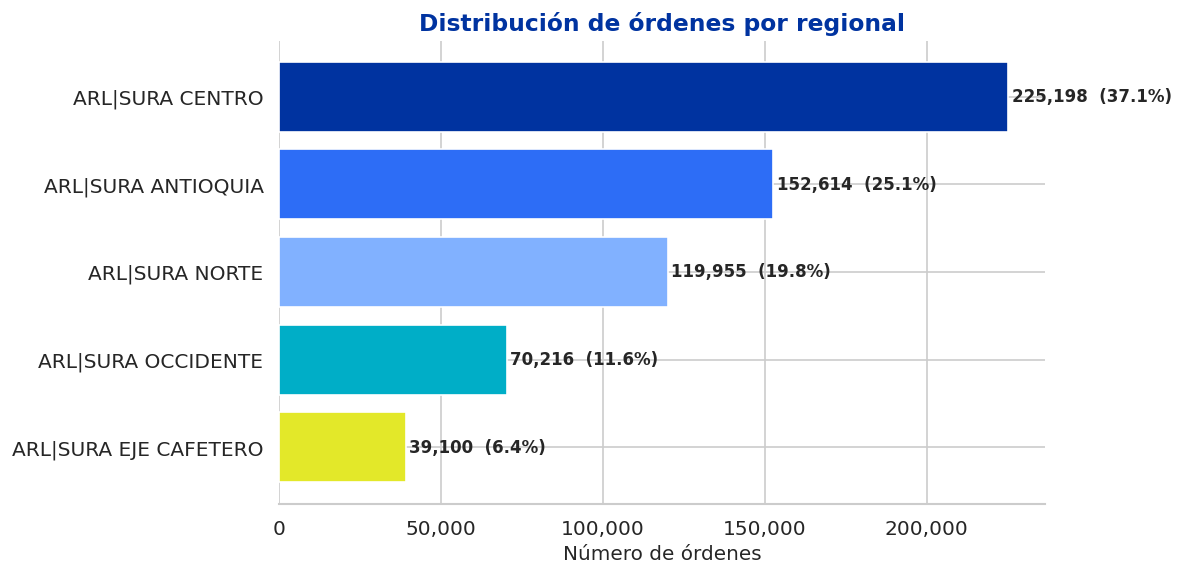

In [0]:
reg_pd = safe_toPandas(
    ordenes_sp
    .groupBy('Nombre_Regional').count()
    .orderBy(F.desc('count'))
    .limit(5)
).set_index('Nombre_Regional')['count']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(reg_pd.index[::-1], reg_pd.values[::-1],
               color=SURA_PAL[:5][::-1], edgecolor='white')

for bar, val in zip(bars, reg_pd.values[::-1]):
    pct = val / reg_pd.sum() * 100
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}  ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
    
ax.set_xlabel('Número de órdenes')
ax.set_title('Distribución de órdenes por regional', fontweight='bold', color=SURA_BLUE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(left=True)

plt.tight_layout()
plt.show()

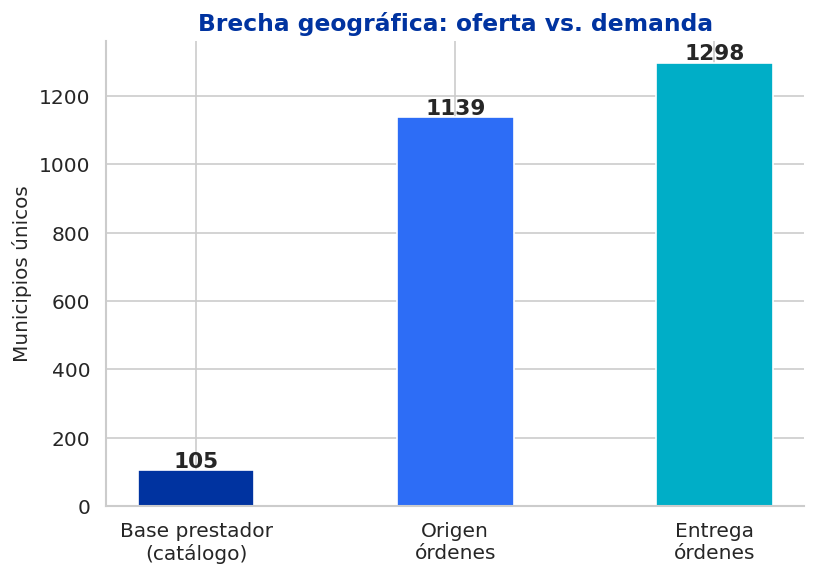

Brecha: 1193 municipios de entrega sin prestador local de base


In [0]:
# Brecha geográfica: municipios de prestadores vs municipios de entrega
mun_catalogo = catalogo_sp.select('DSMUNICIPIO').distinct().count()
mun_origen   = ordenes_sp.select('Municipio_Origen_Desc').distinct().count()
mun_entrega  = ordenes_sp.select('Municipio_Entrega_Desc').distinct().count()

fig, ax = plt.subplots(figsize=(7, 5))
cats  = ['Base prestador\n(catálogo)', 'Origen\nórdenes', 'Entrega\nórdenes']
vals  = [mun_catalogo, mun_origen, mun_entrega]
bars  = ax.bar(cats, vals, color=[SURA_BLUE, SURA_MED, SURA_ACCENT], width=0.45, edgecolor='white')

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Municipios únicos')
ax.set_title('Brecha geográfica: oferta vs. demanda', fontweight='bold', color=SURA_BLUE)

sns.despine()

plt.tight_layout()
plt.show()

print(f'Brecha: {mun_entrega - mun_catalogo} municipios de entrega sin prestador local de base')

---
## 4. Análisis de órdenes de compra

### 4.1 Estado de las órdenes

                           Órdenes      %
Estado_Orden_Desc                        
FACTURADO                   425136  70.00
LEGALIZADO                  171724  28.28
APROBADO                     10177   1.68
H                              208   0.03
PENDIENTE                       44   0.01
U                               17   0.00
VIDEOCHAT                       12   0.00
DOMICILIO                        5   0.00
TELEFONICO                       3   0.00
BLOQUEADO                        2   0.00
PLAN DE EDUCACIÓN VIRTUAL        1   0.00
FACTURA                          1   0.00
                                 1   0.00

Total: 607,331


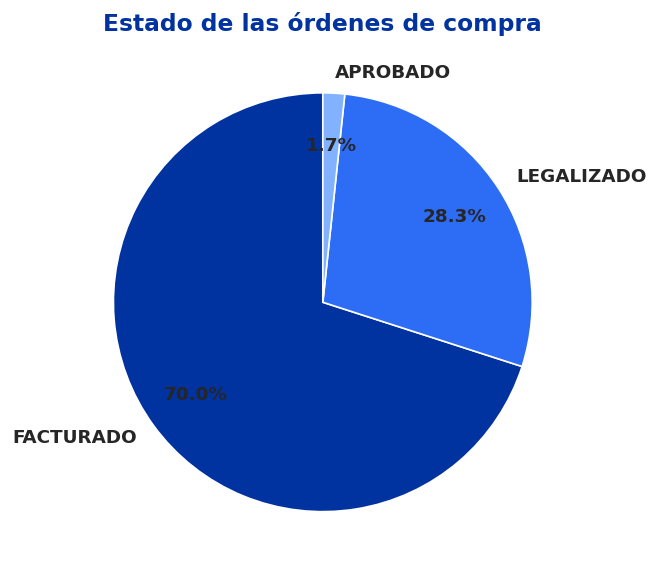

In [0]:
estado_oc_pd = safe_toPandas(
    ordenes_sp
    .groupBy('Estado_Orden_Desc').count()
    .orderBy(F.desc('count'))
).set_index('Estado_Orden_Desc')['count']

total_oc = estado_oc_pd.sum()
df_e = pd.DataFrame({'Órdenes': estado_oc_pd,
                     '%': (estado_oc_pd / total_oc * 100).round(2)})
print(df_e.to_string())
print(f'\nTotal: {total_oc:,}')

# Pie top 3
fig, ax = plt.subplots(figsize=(7, 5))
top3 = estado_oc_pd.head(3)

ax.pie(top3.values, labels=top3.index, autopct='%1.1f%%', pctdistance=0.75,
       colors=[SURA_BLUE, SURA_MED, SURA_LIGHT], startangle=90,
       textprops={'fontsize': 11, 'fontweight':'bold'})

ax.set_title('Estado de las órdenes de compra', fontweight='bold', color=SURA_BLUE)

plt.tight_layout()
plt.show()

### 4.2 Clasificación de servicios y tipo de red

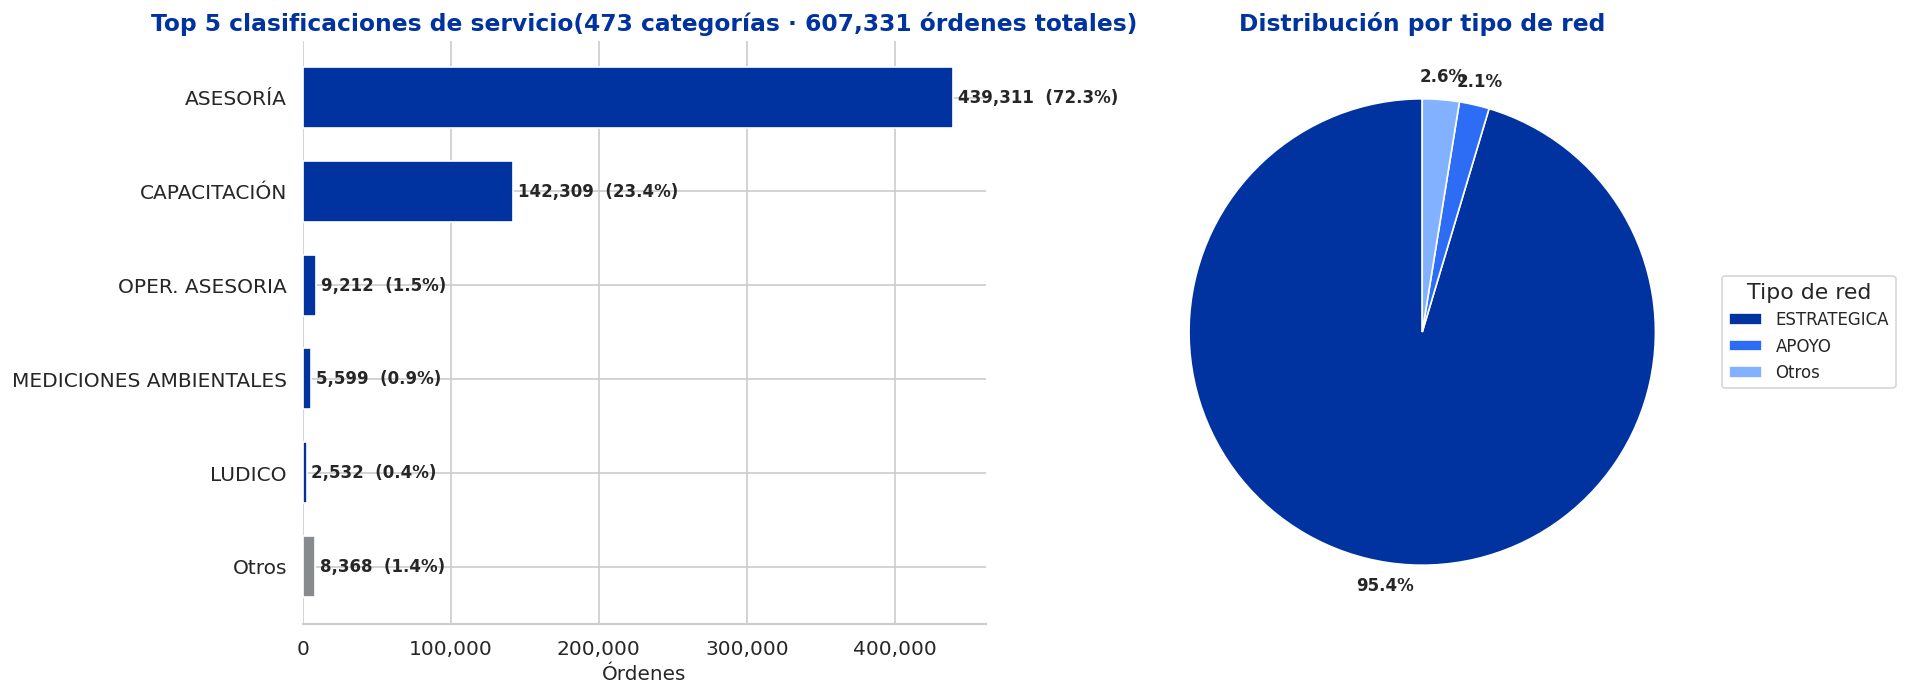

In [0]:
TOP_N = 5

# Clasificación: top N + Otros
clasif_all = safe_toPandas(
    ordenes_sp
    .groupBy('Clasificacion_Desc').count()
    .orderBy(F.desc('count'))
).set_index('Clasificacion_Desc')['count']

total_clasif  = clasif_all.sum()
top_clasif    = clasif_all.head(TOP_N)
otros_clasif  = total_clasif - top_clasif.sum()
clasif_pd     = (pd.concat([top_clasif, pd.Series({'Otros': otros_clasif})])
                 if otros_clasif > 0 else top_clasif)
n_clasif      = clasif_all.shape[0]

# Tipo de red
red_pd = safe_toPandas(
    ordenes_sp
    .groupBy('Tipo_Red_Desc').count()
    .orderBy(F.desc('count'))
).set_index('Tipo_Red_Desc')['count']

threshold = 0.02  # 2%
red_pct = red_pd / red_pd.sum()
red_main = red_pd[red_pct >= threshold].copy()
otros = red_pd[red_pct < threshold].sum()

if otros > 0:
    red_main['Otros'] = otros

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras horizontales — clasificación
ax = axes[0]
bar_colors = [SURA_BLUE if l != 'Otros' else '#888B8D'
              for l in clasif_pd.index[::-1]]
bars = ax.barh(clasif_pd.index[::-1], clasif_pd.values[::-1],
               color=bar_colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, clasif_pd.values[::-1]):
    pct = val / total_clasif * 100
    if pct > 0.3:
        ax.text(bar.get_width() + total_clasif * 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,.0f}  ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
        
ax.set_xlabel('Órdenes')
ax.set_title(
    f'Top {TOP_N} clasificaciones de servicio'
    f'({n_clasif} categorías · {total_clasif:,.0f} órdenes totales)',
    fontweight='bold', color=SURA_BLUE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(ax=ax, left=True)

# Pie — tipo de red
ax = axes[1]

def autopct_func(pct):
    return f'{pct:.1f}%' if pct > 1 else ''

wedges, texts, autotexts = ax.pie(red_main.values, labels=None, autopct=autopct_func,
       colors=SURA_PAL[:len(red_main)], startangle=90, pctdistance=1.1,
       textprops={'fontsize': 10, 'fontweight':'bold'})

ax.legend(wedges, red_main.index, title="Tipo de red", loc="center left",
    bbox_to_anchor=(1, 0.5), fontsize=10)
ax.set_title('Distribución por tipo de red', fontweight='bold', color=SURA_BLUE)

plt.tight_layout()
plt.show()

### 4.3 Macrosegmentación

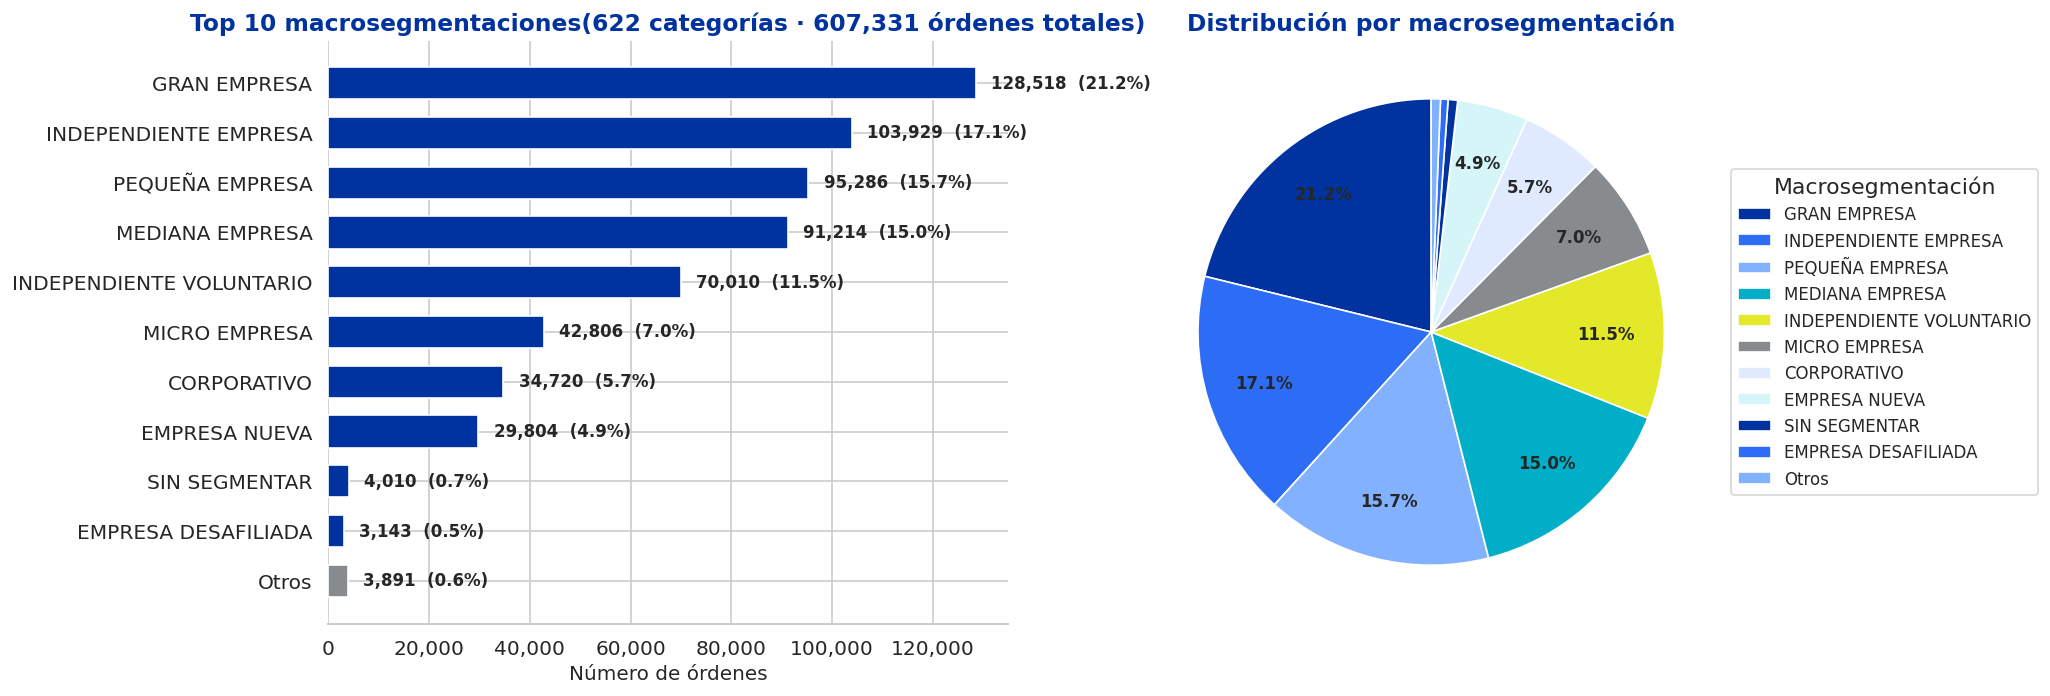

In [0]:
TOP_N = 10

macro_all   = safe_toPandas(
    ordenes_sp
    .groupBy('Macrosegmentacion_Desc').count()
    .orderBy(F.desc('count'))
).set_index('Macrosegmentacion_Desc')['count']

total_macro  = macro_all.sum()
top_macro    = macro_all.head(TOP_N)
otros_macro  = total_macro - top_macro.sum()
macro_pd     = (pd.concat([top_macro, pd.Series({'Otros': otros_macro})])
                if otros_macro > 0 else top_macro)
n_categorias = macro_all.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Barras horizontales
ax = axes[0]
bar_colors = [SURA_BLUE if l != 'Otros' else '#888B8D'
              for l in macro_pd.index[::-1]]
              
bars = ax.barh(macro_pd.index[::-1], macro_pd.values[::-1],
               color=bar_colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, macro_pd.values[::-1]):
    pct = val / total_macro * 100
    if pct > 0.3:
        ax.text(bar.get_width() + total_macro * 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,.0f}  ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
        
ax.set_xlabel('Número de órdenes')
ax.set_title(
    f'Top {TOP_N} macrosegmentaciones'
    f'({n_categorias} categorías · {total_macro:,.0f} órdenes totales)',
    fontweight='bold', color=SURA_BLUE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(ax=ax, left=True)

# Pie con las mismas categorías
ax = axes[1]

def autopct_func(pct):
    return f'{pct:.1f}%' if pct > 1 else ''

pie_colors = SURA_PAL[:len(macro_pd)]

wedges, texts, autotexts = ax.pie(macro_pd.values, labels=None, 
    autopct=autopct_func, colors=pie_colors, startangle=90,
    textprops={'fontsize': 10, 'fontweight':'bold'}, pctdistance=0.75)
    
ax.legend(wedges, macro_pd.index, title="Macrosegmentación",
    loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
ax.set_title('Distribución por macrosegmentación', fontweight='bold', color=SURA_BLUE)

plt.tight_layout()
plt.show()

### 4.4 Carga operativa por prestador — PROBLEMA #1

In [0]:
carga_pd = safe_toPandas(
    ordenes_sp
    .groupBy('Dni_Prestador').count()
).set_index('Dni_Prestador')['count']

print('=== Distribución de órdenes por prestador ===')
print(carga_pd.describe().to_string())
print(f'\nPrestadores con > 500 órdenes : {(carga_pd > 500).sum()}')
print(f'Prestadores con > 1.000 órdenes: {(carga_pd > 1000).sum()}')
print(f'\nMediana = {carga_pd.median():.0f}  vs  Media = {carga_pd.mean():.1f} — distribución muy sesgada')

=== Distribución de órdenes por prestador ===
count      6848.000000
mean         88.687354
std        1897.828614
min           1.000000
25%           5.000000
50%          22.500000
75%          78.250000
max      141778.000000

Prestadores con > 500 órdenes : 43
Prestadores con > 1.000 órdenes: 12

Mediana = 22  vs  Media = 88.7 — distribución muy sesgada


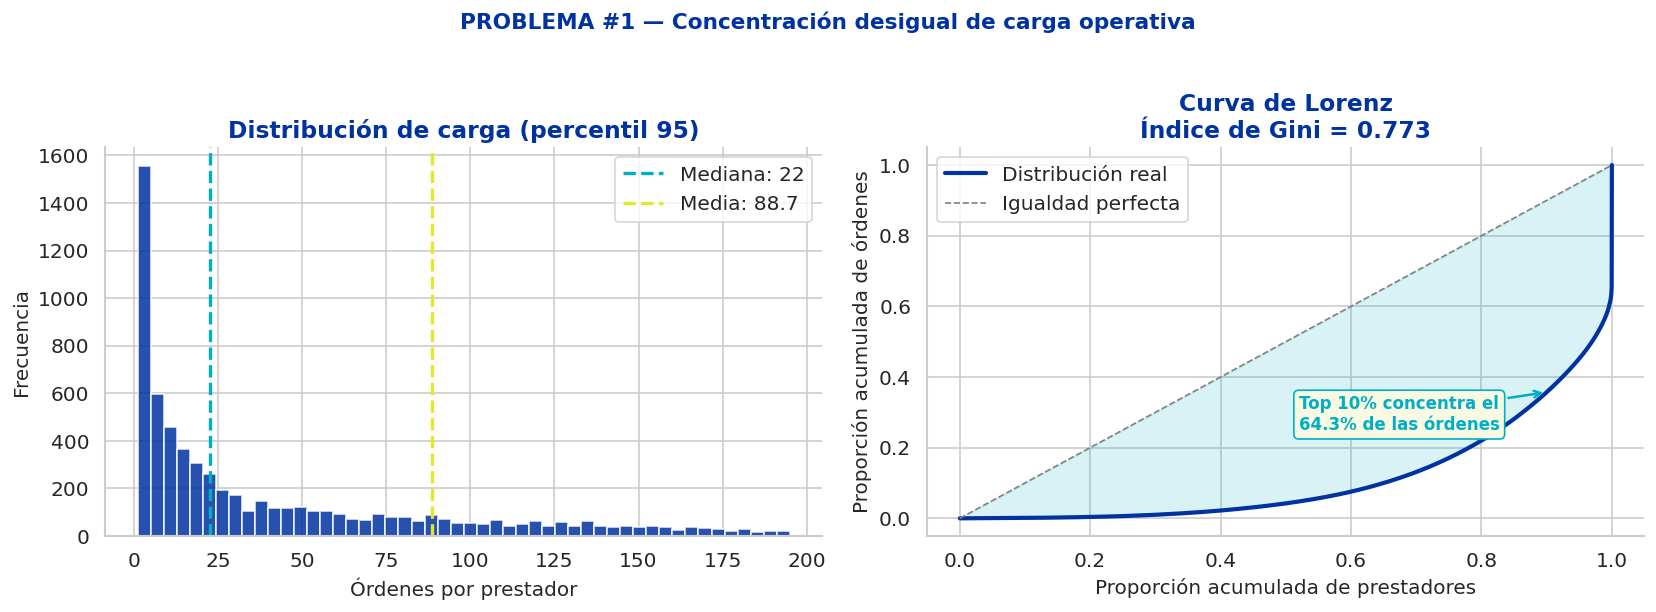

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma (percentil 95)
ax = axes[0]
c95 = carga_pd[carga_pd <= carga_pd.quantile(0.95)]
ax.hist(c95, bins=50, color=SURA_BLUE, edgecolor='white', alpha=0.85)
ax.axvline(carga_pd.median(), color=SURA_ACCENT, lw=2, linestyle='--',
           label=f'Mediana: {carga_pd.median():.0f}')
ax.axvline(carga_pd.mean(), color='#E3E829', lw=2, linestyle='--',
           label=f'Media: {carga_pd.mean():.1f}')
ax.set_xlabel('Órdenes por prestador')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de carga (percentil 95)', fontweight='bold', color=SURA_BLUE)
ax.legend()
sns.despine(ax=ax)

# Curva de Lorenz
ax = axes[1]
cs = np.sort(carga_pd.values)
n  = len(cs)
cum_share = np.cumsum(cs) / cs.sum()
pop_share = np.arange(1, n + 1) / n
gini = 1 - 2 * np.trapz(cum_share, pop_share)

ax.plot(pop_share, cum_share, color=SURA_BLUE, lw=2.5, label='Distribución real')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Igualdad perfecta')

ax.fill_between(pop_share, cum_share, pop_share, alpha=0.15, color=SURA_ACCENT)

ax.set_xlabel('Proporción acumulada de prestadores')
ax.set_ylabel('Proporción acumulada de órdenes')
ax.set_title(f'Curva de Lorenz\nÍndice de Gini = {gini:.3f}', fontweight='bold', color=SURA_BLUE)
ax.legend()

p90 = int(0.9 * n)
ax.annotate(f'Top 10% concentra el\n{(1 - cum_share[p90])*100:.1f}% de las órdenes',
            xy=(0.9, cum_share[p90]), xytext=(0.52, 0.25),
            arrowprops=dict(arrowstyle='->', color=SURA_ACCENT, lw=1.5),
            fontsize=10, color=SURA_ACCENT, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#F9FAE1', edgecolor=SURA_ACCENT))

sns.despine(ax=ax)

plt.suptitle('PROBLEMA #1 — Concentración desigual de carga operativa',
             fontsize=13, fontweight='bold', color=SURA_BLUE, y=1.02)

plt.tight_layout()
plt.show()

In [0]:
# Top 20 prestadores
top20 = carga_pd.sort_values(ascending=False).head(20).reset_index()
top20.columns = ['DNI_Prestador', 'Órdenes']
top20['% total']    = (top20['Órdenes'] / carga_pd.sum() * 100).round(2)
top20['% acumulado'] = top20['% total'].cumsum().round(2)
top20.index = range(1, 21)
display(spark.createDataFrame(top20.astype(str)))

DNI_Prestador,Órdenes,% total,% acumulado
1e91fd90c0,141778,23.34,23.34
1f48fac6e6,67018,11.03,34.37
1b1dcdc550,4772,0.79,35.16
b811e034bc,3748,0.62,35.78
0e9df110a8,2159,0.36,36.14
a0c3502691,2007,0.33,36.47
2bbf9e8852,1962,0.32,36.79
5708b4378b,1484,0.24,37.03
886a59f0df,1318,0.22,37.25
1edd4fc7b9,1263,0.21,37.46


---
## 5. Análisis de programaciones y cancelaciones (2025)

### 5.1 Estado de las programaciones

In [0]:
estado_prog_pd = safe_toPandas(
    tareas_sp
    .groupBy('DSESTADO_PROGRAMACION').count()
    .orderBy(F.desc('count'))
).set_index('DSESTADO_PROGRAMACION')['count']

n_cancel  = int(estado_prog_pd.get('CITA CANCELADA', 0))
total_prog = int(estado_prog_pd.sum())

print(estado_prog_pd.to_string())
print(f'\nTasa de cancelación global: {n_cancel/total_prog*100:.1f}% ({n_cancel:,} de {total_prog:,})')

DSESTADO_PROGRAMACION
CITA EJECUTADA             1298102
CITA CANCELADA              229824
CITA PROGRAMADA              13893
PARCIALMENTE EJECUTADO         524
PARCIALMENTE COMPLETADO        246
CITA REPROGRAMADA              114
RECHAZADA                        6

Tasa de cancelación global: 14.9% (229,824 de 1,542,709)


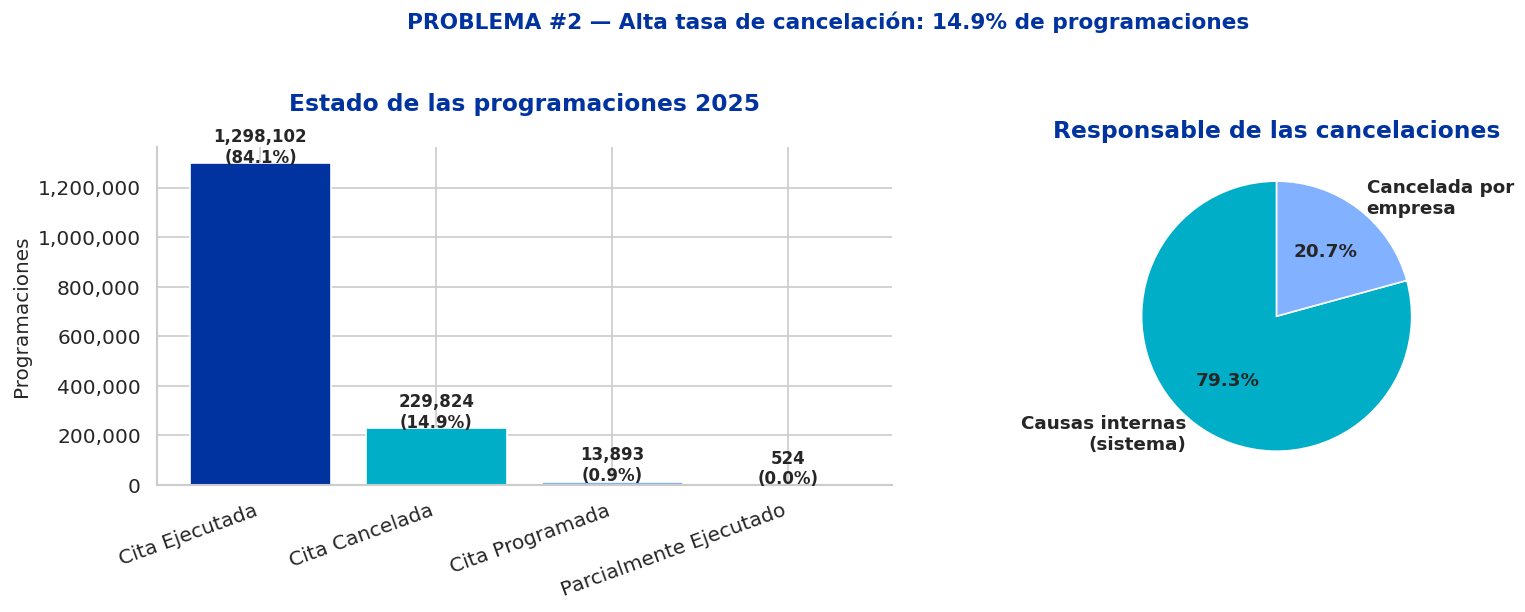

In [0]:
cancela_emp_pd = safe_toPandas(
    tareas_sp
    .filter(F.col('DSESTADO_PROGRAMACION') == 'CITA CANCELADA')
    .groupBy('SNCANCELA_EMPRESA').count()
).set_index('SNCANCELA_EMPRESA')['count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
top_ep = estado_prog_pd.head(4)
bars = ax.bar(range(len(top_ep)), top_ep.values,
              color=[SURA_BLUE, SURA_ACCENT, SURA_LIGHT, '#E3E829'], edgecolor='white')
ax.set_xticks(range(len(top_ep)))
ax.set_xticklabels([s.title() for s in top_ep.index], rotation=20, ha='right')

total = estado_prog_pd.sum()
for bar, val in zip(bars, top_ep.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{val:,.0f}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
    
ax.set_ylabel('Programaciones')
ax.set_title('Estado de las programaciones 2025\n', fontweight='bold', color=SURA_BLUE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(ax=ax)

ax = axes[1]
vals_ce  = [int(cancela_emp_pd.get('N', 0)), int(cancela_emp_pd.get('S', 0))]
labels_ce = ['Causas internas\n(sistema)', 'Cancelada por\nempresa']

ax.pie(vals_ce, labels=labels_ce, autopct='%1.1f%%', colors=[SURA_ACCENT, SURA_LIGHT], 
       startangle=90, textprops={'fontsize': 11, 'fontweight':'bold'})
ax.set_title('Responsable de las cancelaciones', fontweight='bold', color=SURA_BLUE)

plt.suptitle('PROBLEMA #2 — Alta tasa de cancelación: 14.9% de programaciones',
             fontsize=13, fontweight='bold', color=SURA_BLUE, y=1.02)

plt.tight_layout()
plt.show()

### 5.2 Tasa de cancelación por prestador

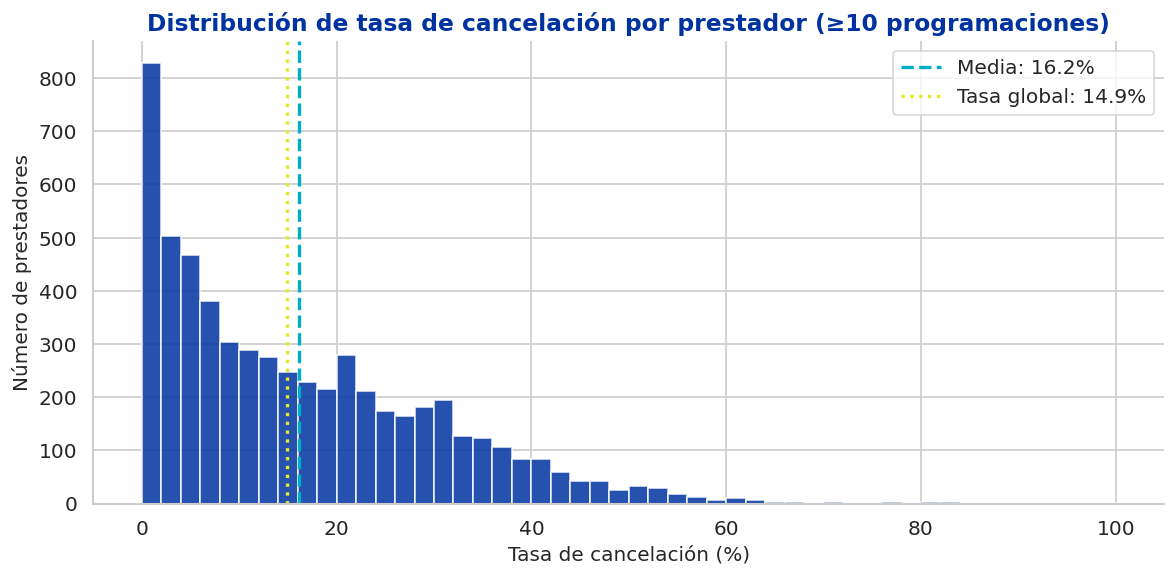

Prestadores con tasa > 30%: 1006
Prestadores con tasa > 50%: 120


In [0]:
total_prest_sp  = tareas_sp.groupBy('DNI_PRESTADOR').count().withColumnRenamed('count', 'total')
cancel_prest_sp = (tareas_sp
                   .filter(F.col('DSESTADO_PROGRAMACION') == 'CITA CANCELADA')
                   .groupBy('DNI_PRESTADOR').count()
                   .withColumnRenamed('count', 'canceladas'))

tasa_sp = (total_prest_sp
           .join(cancel_prest_sp, on='DNI_PRESTADOR', how='left')
           .fillna(0, subset=['canceladas'])
           .filter(F.col('total') >= 10)
           .withColumn('tasa_cancel', F.col('canceladas') / F.col('total')))

tasa_pd = safe_toPandas(tasa_sp.select('tasa_cancel'))['tasa_cancel']

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tasa_pd * 100, bins=50, color=SURA_BLUE, edgecolor='white', alpha=0.85)
ax.axvline(tasa_pd.mean() * 100, color=SURA_ACCENT, lw=2, linestyle='--',
           label=f'Media: {tasa_pd.mean()*100:.1f}%')
ax.axvline(14.9, color='#E3E829', lw=2, linestyle=':',
           label='Tasa global: 14.9%')
ax.set_xlabel('Tasa de cancelación (%)')
ax.set_ylabel('Número de prestadores')
ax.set_title('Distribución de tasa de cancelación por prestador (≥10 programaciones)',
             fontweight='bold', color=SURA_BLUE)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f'Prestadores con tasa > 30%: {(tasa_pd > 0.30).sum()}')
print(f'Prestadores con tasa > 50%: {(tasa_pd > 0.50).sum()}')

### 5.3 Modalidad de servicio y duración

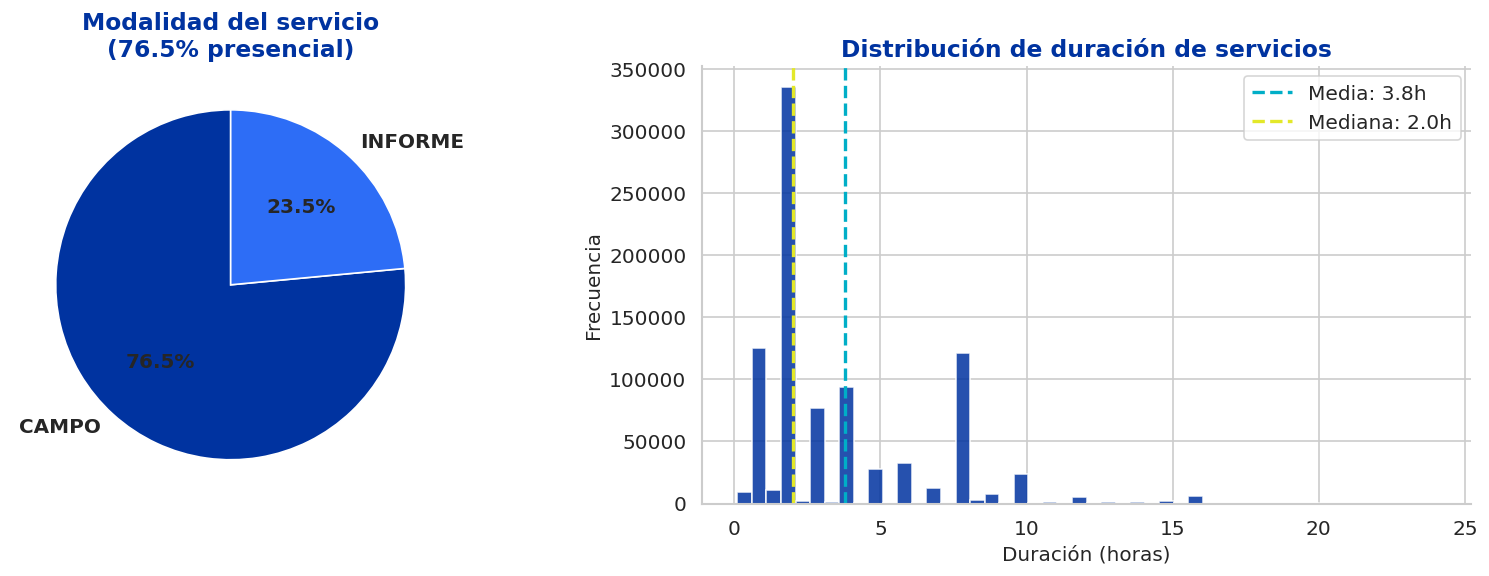

In [0]:
tipo_pd = safe_toPandas(
    tareas_sp
    .groupBy('TIPO_PROGRAMACION').count()
    .orderBy(F.desc('count'))
).set_index('TIPO_PROGRAMACION')['count']

dur_pd  = safe_toPandas(
    tareas_sp
    .filter((F.col('DURACION').cast('double') > 0) &
            (F.col('DURACION').cast('double') <= 24))
    .select(F.col('DURACION').cast('double').alias('dur'))
)['dur']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.pie(tipo_pd.values, labels=tipo_pd.index, autopct='%1.1f%%',
       colors=[SURA_BLUE, SURA_MED], startangle=90, textprops={'fontsize': 12, 'fontweight':'bold'})
ax.set_title('Modalidad del servicio\n(76.5% presencial)', fontweight='bold', color=SURA_BLUE)

ax = axes[1]
ax.hist(dur_pd, bins=48, color=SURA_BLUE, edgecolor='white', alpha=0.85)
ax.axvline(dur_pd.mean(), color=SURA_ACCENT, lw=2, linestyle='--',
           label=f'Media: {dur_pd.mean():.1f}h')
ax.axvline(dur_pd.median(), color='#E3E829', lw=2, linestyle='--',
           label=f'Mediana: {dur_pd.median():.1f}h')
ax.set_xlabel('Duración (horas)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de duración de servicios', fontweight='bold', color=SURA_BLUE)
ax.legend()
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### 5.4 Estado de los informes

In [0]:
informe_pd = safe_toPandas(
    tareas_sp
    .filter(F.col('DSESTADO_INFORME').isNotNull())
    .groupBy('DSESTADO_INFORME').count()
    .orderBy(F.desc('count'))
).set_index('DSESTADO_INFORME')['count']

rechazados = int(informe_pd.get('RECHAZADO', 0)) + int(informe_pd.get('RE', 0))
print(informe_pd.to_string())
print(f'\nTasa de rechazo: {rechazados / informe_pd.sum() * 100:.2f}% ({rechazados:,} de {informe_pd.sum():,})')

DSESTADO_INFORME
                1257444
APROBADO         141843
AP               125427
PA                14438
PRE-APROBADO       2558
RECHAZADO           965
RE                   34

Tasa de rechazo: 0.06% (999 de 1,542,709)


---
## 6. Caracterización de la demanda empresarial

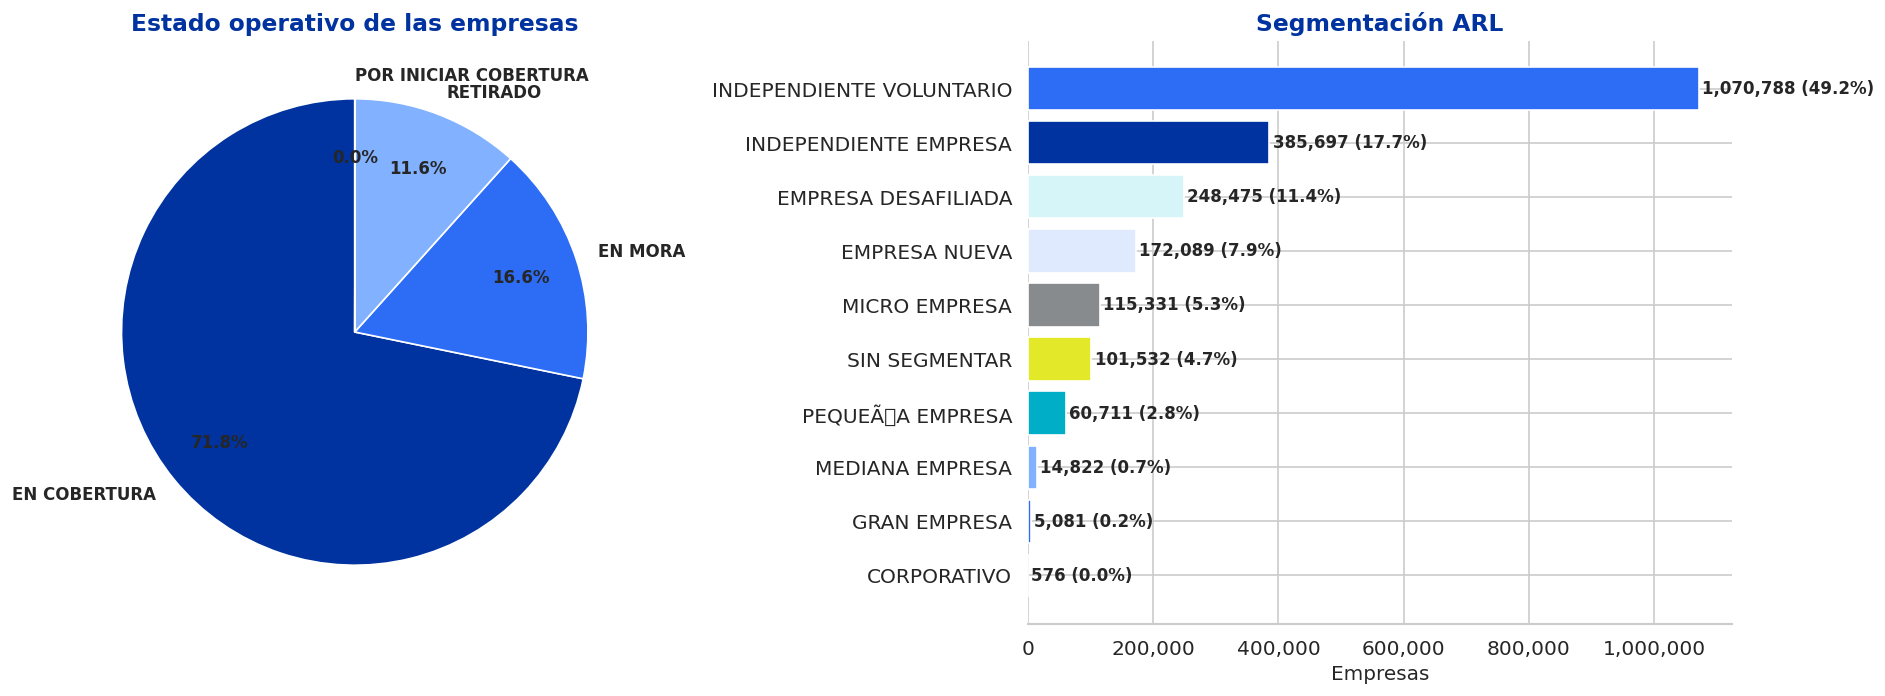

In [0]:
estado_emp_pd = safe_toPandas(
    empresas_sp
    .groupBy('ESTADO_EMPRESA').count()
    .orderBy(F.desc('count'))
).set_index('ESTADO_EMPRESA')['count']

segm_pd = safe_toPandas(
    empresas_sp
    .groupBy('Segmentacion_Arl_Desc').count()
    .orderBy(F.desc('count'))
).set_index('Segmentacion_Arl_Desc')['count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.pie(estado_emp_pd.values, labels=estado_emp_pd.index, autopct='%1.1f%%',
       colors=SURA_PAL[:len(estado_emp_pd)], startangle=90, pctdistance=0.75, 
       textprops={'fontsize': 10, 'fontweight':'bold'})
ax.set_title('Estado operativo de las empresas', fontweight='bold', color=SURA_BLUE)

ax = axes[1]
bars = ax.barh(segm_pd.index[::-1], segm_pd.values[::-1],
               color=SURA_PAL[:len(segm_pd)], edgecolor='white')

for bar, val in zip(bars, segm_pd.values[::-1]):
    pct = val / segm_pd.sum() * 100
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
    
ax.set_xlabel('Empresas')
ax.set_title('Segmentación ARL', fontweight='bold', color=SURA_BLUE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.show()

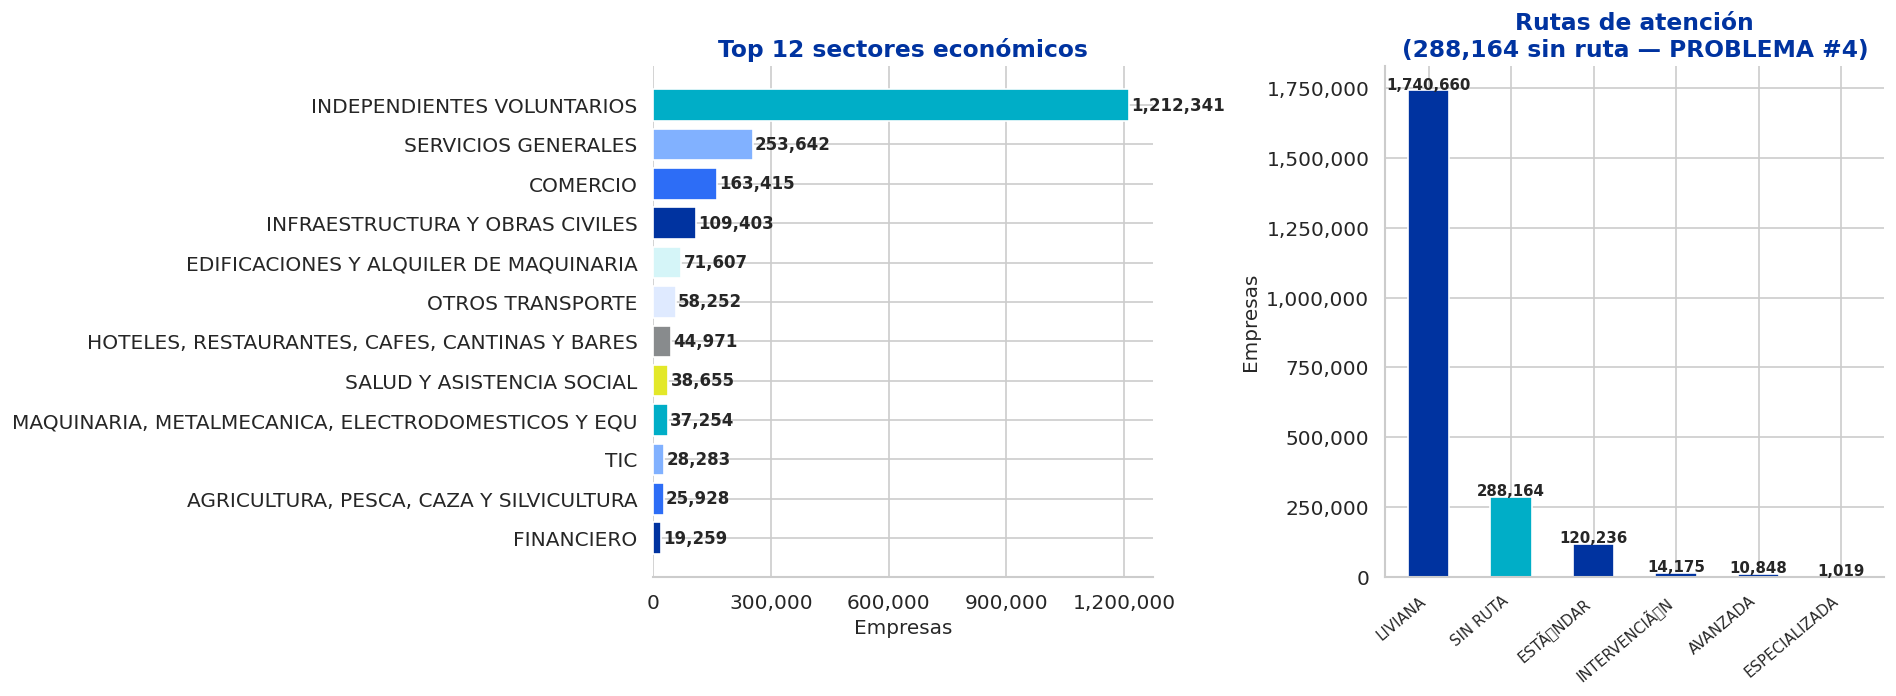

In [0]:
sector_pd = safe_toPandas(
    empresas_sp
    .groupBy('Sector_Economico_Desc').count()
    .orderBy(F.desc('count'))
    .limit(12)
).set_index('Sector_Economico_Desc')['count']

ruta_pd = safe_toPandas(
    empresas_sp
    .groupBy('Ruta_Atencion').count()
    .orderBy(F.desc('count'))
).set_index('Ruta_Atencion')['count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
bars = ax.barh(sector_pd.index[::-1], sector_pd.values[::-1],
               color=SURA_PAL[:len(sector_pd)], edgecolor='white')

for bar, val in zip(bars, sector_pd.values[::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=10, fontweight='bold')
    
ax.set_xlabel('Empresas')
ax.set_title('Top 12 sectores económicos', fontweight='bold', color=SURA_BLUE)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(ax=ax, left=True)

ax = axes[1]
sin_ruta = int(ruta_pd.get('SIN RUTA', 0))
colors_r = [SURA_ACCENT if r == 'SIN RUTA' else SURA_BLUE for r in ruta_pd.index]
bars = ax.bar(range(len(ruta_pd)), ruta_pd.values, color=colors_r, width=0.5, edgecolor='white')
ax.set_xticks(range(len(ruta_pd)))
ax.set_xticklabels(ruta_pd.index, rotation=40, ha='right', fontsize=9)

for bar, val in zip(bars, ruta_pd.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')
    
ax.set_ylabel('Empresas')
ax.set_title(f'Rutas de atención\n({sin_ruta:,} sin ruta — PROBLEMA #4)',
             fontweight='bold', color=SURA_BLUE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(ax=ax)

plt.tight_layout()
plt.show()

---
## 7. Catálogo de habilitaciones (oferta de prestadores)

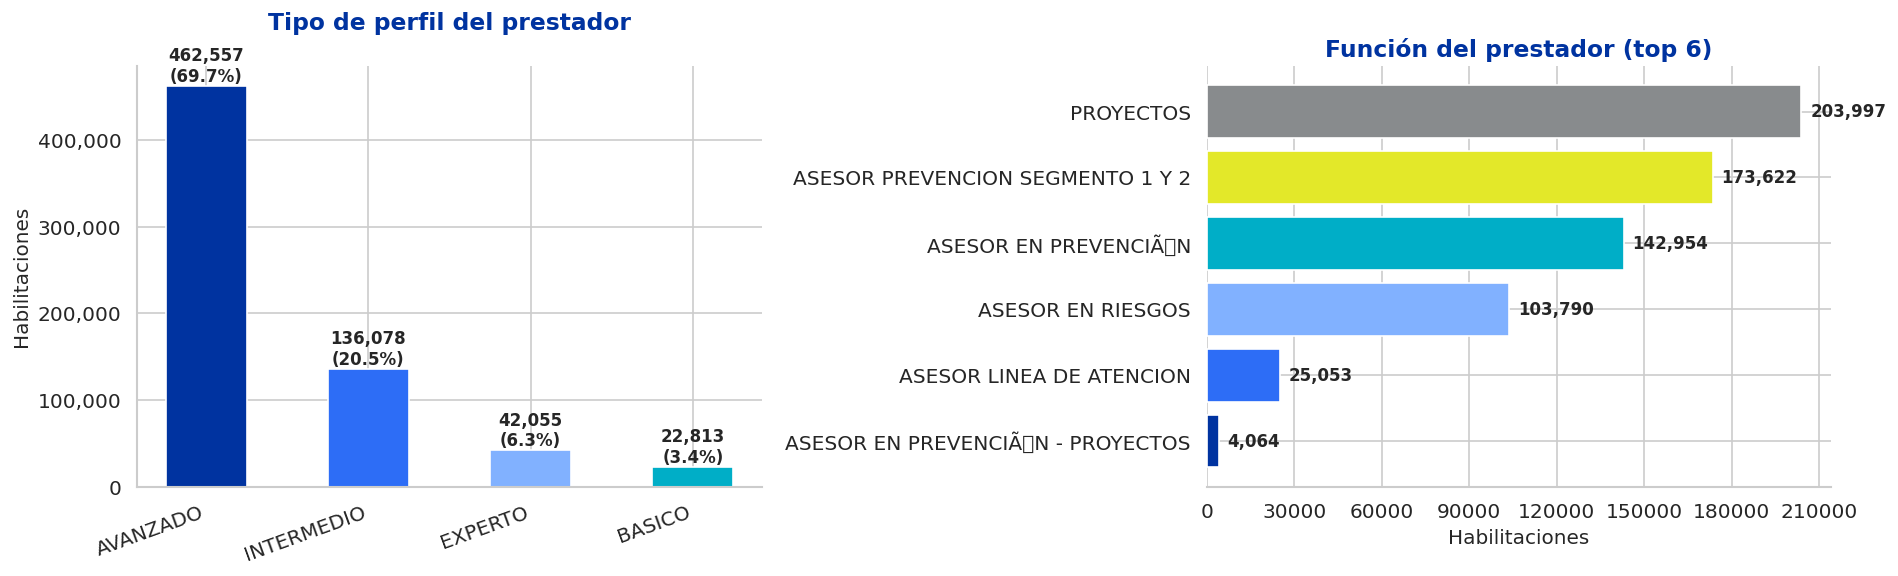

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

perfil_pd = safe_toPandas(
    catalogo_sp
    .groupBy('DSTIPO_PERFIL').count()
    .orderBy(F.desc('count'))
).set_index('DSTIPO_PERFIL')['count']

ax = axes[0]
bars = ax.bar(range(len(perfil_pd)), perfil_pd.values,
              color=SURA_PAL[:len(perfil_pd)], width=0.5, edgecolor='white')
ax.set_xticks(range(len(perfil_pd)))
ax.set_xticklabels(perfil_pd.index, rotation=20, ha='right')

for bar, val in zip(bars, perfil_pd.values):
    pct = val / catalogo_sp.count() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,.0f}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
    
ax.set_ylabel('Habilitaciones')
ax.set_title('Tipo de perfil del prestador\n', fontweight='bold', color=SURA_BLUE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(ax=ax)

funcion_pd = safe_toPandas(
    catalogo_sp
    .groupBy('FUNCION_PRESTADOR').count()
    .orderBy(F.desc('count'))
    .limit(6)
).set_index('FUNCION_PRESTADOR')['count']

ax = axes[1]
bars = ax.barh(funcion_pd.index[::-1], funcion_pd.values[::-1],
               color=SURA_PAL[:len(funcion_pd)], edgecolor='white')

for bar, val in zip(bars, funcion_pd.values[::-1]):
    ax.text(bar.get_width() + 3000, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=10, fontweight='bold')
            
ax.set_xlabel('Habilitaciones')
ax.set_title('Función del prestador (top 6)', fontweight='bold', color=SURA_BLUE)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.show()

=== Capacidad por prestador (horas) ===
count    1422.000000
mean      157.191505
std        47.806943
min         0.000000
25%       169.260000
50%       169.260000
75%       169.260000
max       185.000000

=== Habilitaciones por prestador ===
count    1422.000000
mean      466.598453
std       328.586795
min         1.000000
25%       174.000000
50%       422.000000
75%       644.500000
max      3293.000000


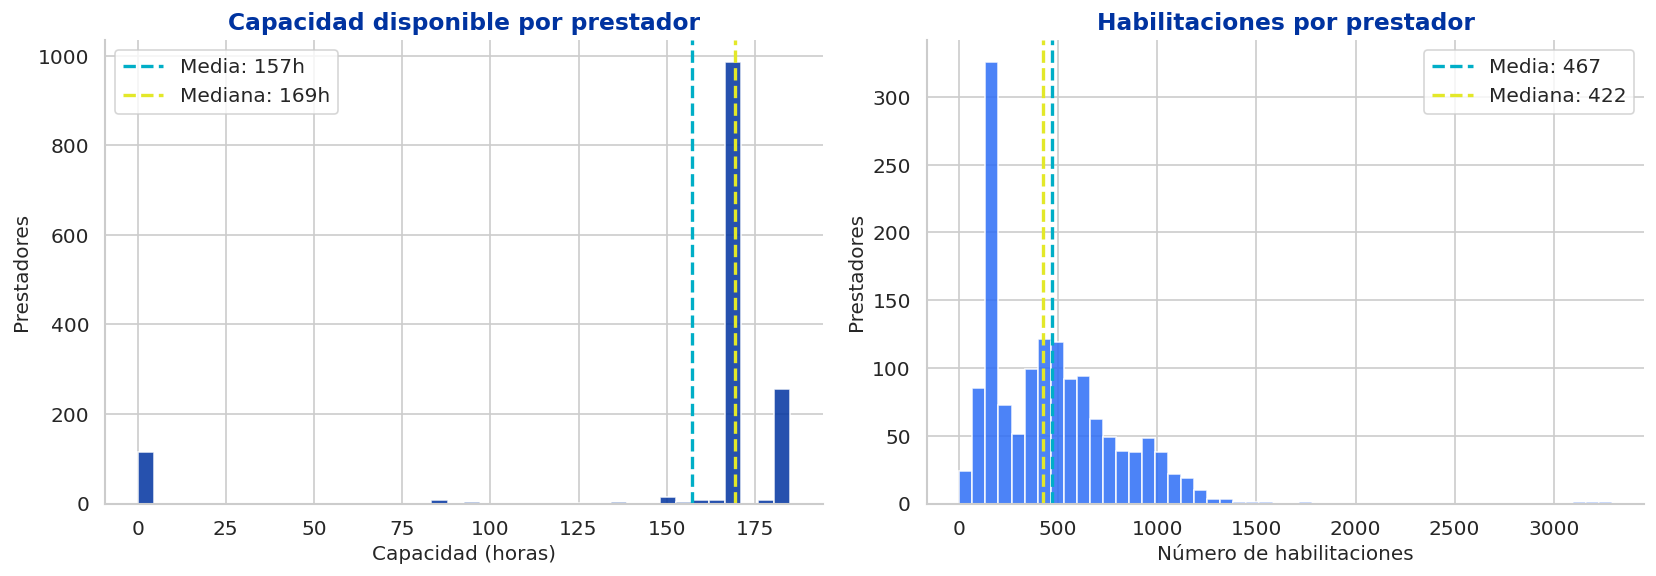

In [0]:
# Capacidad y habilitaciones por prestador
cap_pd = safe_toPandas(
    catalogo_sp
    .groupBy('DNI_PRESTADOR')
    .agg(F.first('CAPACIDAD').cast('double').alias('capacidad'),
         F.count('*').alias('habilitaciones'))
)

print('=== Capacidad por prestador (horas) ===')
print(cap_pd['capacidad'].dropna().describe().to_string())
print('\n=== Habilitaciones por prestador ===')
print(cap_pd['habilitaciones'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
c = cap_pd['capacidad'].dropna()
ax.hist(c, bins=40, color=SURA_BLUE, edgecolor='white', alpha=0.85)
ax.axvline(c.mean(), color=SURA_ACCENT, lw=2, linestyle='--',
           label=f'Media: {c.mean():.0f}h')
ax.axvline(c.median(), color='#E3E829', lw=2, linestyle='--',
           label=f'Mediana: {c.median():.0f}h')
ax.set_xlabel('Capacidad (horas)')
ax.set_ylabel('Prestadores')
ax.set_title('Capacidad disponible por prestador', fontweight='bold', color=SURA_BLUE)
ax.legend()
sns.despine(ax=ax)

ax = axes[1]
h = cap_pd['habilitaciones']
ax.hist(h, bins=50, color=SURA_MED, edgecolor='white', alpha=0.85)
ax.axvline(h.mean(), color=SURA_ACCENT, lw=2, linestyle='--',
           label=f'Media: {h.mean():.0f}')
ax.axvline(h.median(), color='#E3E829', lw=2, linestyle='--',
           label=f'Mediana: {h.median():.0f}')
ax.set_xlabel('Número de habilitaciones')
ax.set_ylabel('Prestadores')
ax.set_title('Habilitaciones por prestador', fontweight='bold', color=SURA_BLUE)
ax.legend()
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

---
## 8. Dashboard — Resumen de problemas identificados

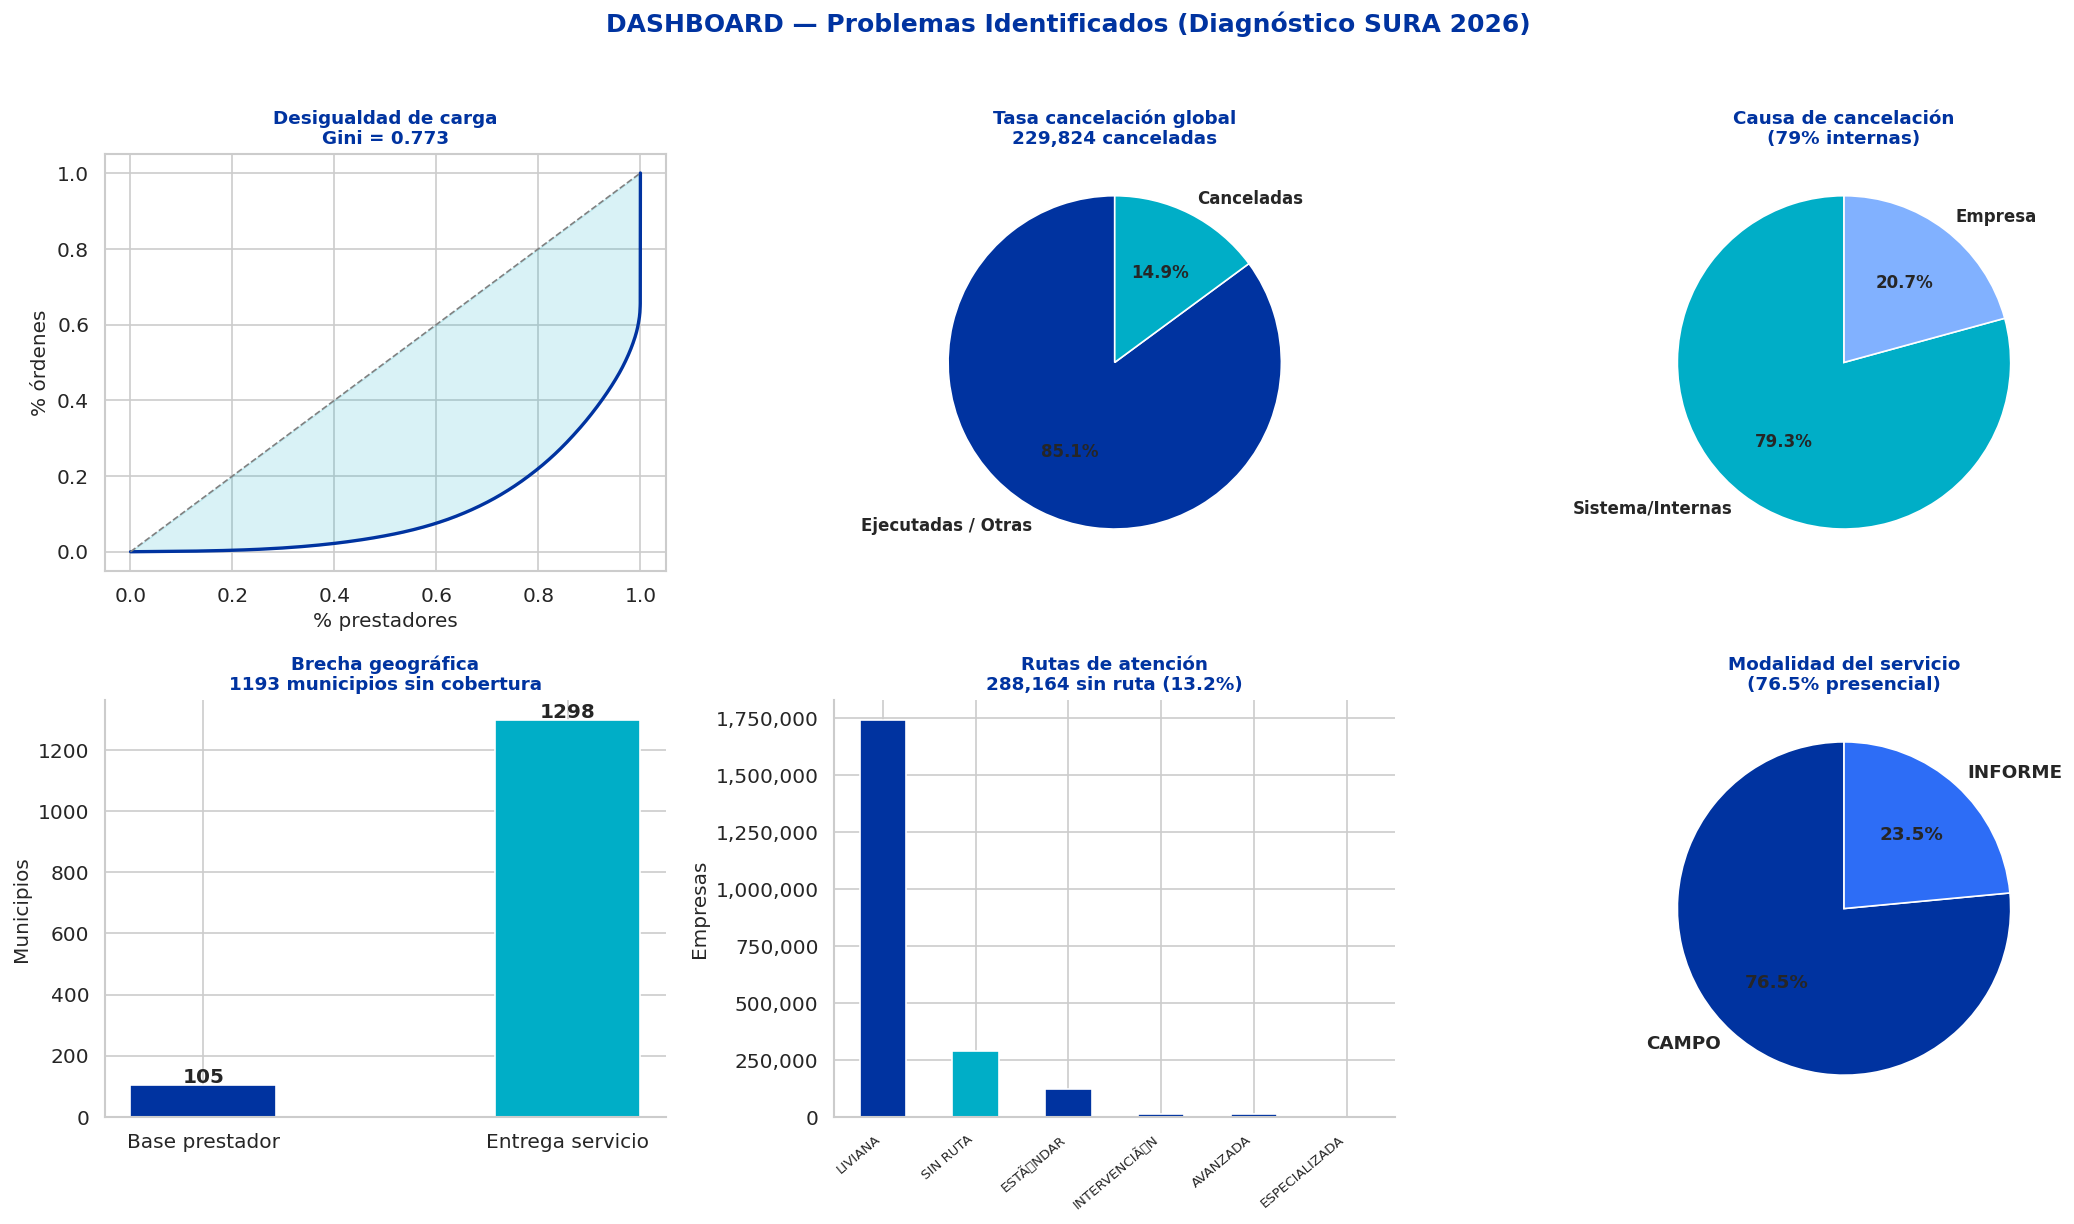

In [0]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DASHBOARD — Problemas Identificados (Diagnóstico SURA 2026)',
             fontsize=15, fontweight='bold', color=SURA_BLUE, y=1.02)

# 1. Lorenz
ax = axes[0, 0]
ax.plot(pop_share, cum_share, color=SURA_BLUE, lw=2)
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)
ax.fill_between(pop_share, cum_share, pop_share, alpha=0.15, color=SURA_ACCENT)
ax.set_title(f'Desigualdad de carga\nGini = {gini:.3f}', fontweight='bold', color=SURA_BLUE, fontsize=11)
ax.set_xlabel('% prestadores'); ax.set_ylabel('% órdenes')

# 2. Tasa cancelación
ax = axes[0, 1]
ax.pie([total_prog - n_cancel, n_cancel],
       labels=['Ejecutadas / Otras', 'Canceladas'],
       autopct='%1.1f%%', colors=[SURA_BLUE, SURA_ACCENT],
       startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax.set_title(f'Tasa cancelación global\n{n_cancel:,} canceladas', fontweight='bold', color=SURA_BLUE, fontsize=11)

# 3. Causa cancelaciones
ax = axes[0, 2]
ax.pie(vals_ce, labels=['Sistema/Internas', 'Empresa'],
       autopct='%1.1f%%', colors=[SURA_ACCENT, SURA_LIGHT],
       startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax.set_title('Causa de cancelación\n(79% internas)', fontweight='bold', color=SURA_BLUE, fontsize=11)

# 4. Brecha geográfica
ax = axes[1, 0]
bars = ax.bar(['Base prestador', 'Entrega servicio'],
              [mun_catalogo, mun_entrega],
              color=[SURA_BLUE, SURA_ACCENT], width=0.4, edgecolor='white')
for bar, val in zip(bars, [mun_catalogo, mun_entrega]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Municipios')
ax.set_title(f'Brecha geográfica\n{mun_entrega - mun_catalogo} municipios sin cobertura',
             fontweight='bold', color=SURA_BLUE, fontsize=11)
sns.despine(ax=ax)

# 5. Rutas de atención
ax = axes[1, 1]
colors_r = [SURA_ACCENT if r == 'SIN RUTA' else SURA_BLUE for r in ruta_pd.index]
ax.bar(range(len(ruta_pd)), ruta_pd.values, color=colors_r, width=0.5, edgecolor='white')
ax.set_xticks(range(len(ruta_pd)))
ax.set_xticklabels(ruta_pd.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Empresas')
ax.set_title(f'Rutas de atención\n{sin_ruta:,} sin ruta ({sin_ruta/ruta_pd.sum()*100:.1f}%)',
             fontweight='bold', color=SURA_BLUE, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine(ax=ax)

# 6. Campo vs Informe
ax = axes[1, 2]
ax.pie(tipo_pd.values, labels=tipo_pd.index, autopct='%1.1f%%',
       colors=[SURA_BLUE, SURA_MED], startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Modalidad del servicio\n(76.5% presencial)', fontweight='bold', color=SURA_BLUE, fontsize=11)

plt.tight_layout()
plt.show()

In [0]:
# Tabla resumen de problemas
problemas = spark.createDataFrame(pd.DataFrame({
    'Problema': [
        '#1 Concentración desigual de carga',
        '#2 Alta tasa de cancelación',
        '#3 Cancelaciones internas (79%)',
        '#4 Brecha geográfica',
        '#5 Empresas sin ruta de atención',
        '#6 Predominio de servicio presencial',
    ],
    'Evidencia': [
        f'Gini={gini:.3f} | Mediana={carga_pd.median():.0f} vs Max={carga_pd.max():,}',
        f'{n_cancel:,} canceladas = {n_cancel/total_prog*100:.1f}% del total',
        f'{vals_ce[0]:,} de {sum(vals_ce):,} cancelaciones = {vals_ce[0]/sum(vals_ce)*100:.1f}%',
        f'{mun_catalogo} municipios de base vs {mun_entrega} de entrega',
        f'{sin_ruta:,} empresas = {sin_ruta/ruta_pd.sum()*100:.1f}% sin ruta definida',
        f'{int(tipo_pd.get("CAMPO",0)):,} servicios presenciales = {tipo_pd.get("CAMPO",0)/tipo_pd.sum()*100:.1f}%',
    ]
}))
display(problemas)

Problema,Evidencia
#1 Concentración desigual de carga,"Gini=0.773 | Mediana=22 vs Max=141,778"
#2 Alta tasa de cancelación,"229,824 canceladas = 14.9% del total"
#3 Cancelaciones internas (79%),"169,699 de 214,093 cancelaciones = 79.3%"
#4 Brecha geográfica,105 municipios de base vs 1298 de entrega
#5 Empresas sin ruta de atención,"288,164 empresas = 13.2% sin ruta definida"
#6 Predominio de servicio presencial,"1,180,064 servicios presenciales = 76.5%"


---
## Conclusión

El análisis cuantitativo soporta los hallazgos presentados en el documento de Diagnóstico y Análisis:

- **Concentración extrema de carga** (Gini > 0.8): el 10% de los prestadores absorbe la mayor parte de las órdenes.
- **14.9% de cancelaciones**, 79% atribuibles a causas internas del sistema.
- **Brecha geográfica** entre municipios de base de prestadores y puntos de entrega.
- **13.2% de empresas sin ruta de atención** definida.
- **76.5% de servicios presenciales**. Proximidad geográfica como factor crítico de asignación.

Estos hallazgos fundamentan la propuesta de un **modelo de clústeres** que optimice la asignación de prestadores, basándose en geografía (ubicación), especialización, capacidad y desempeño histórico.